<a href="https://www.kaggle.com/code/dhruvjain35/triagegeist-clinical-ai-pipeline?scriptVersionId=308824233" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Triagegeist: Stacked Ensemble Clinical Decision Support for Emergency Triage Acuity Prediction

## Clinical Problem Statement

**Every minute matters in the emergency department (ED).** Triage — the rapid assignment of acuity levels to arriving patients — determines who is seen first and who waits. Errors in this process are not abstract: undertriage (assigning a lower-than-warranted severity) delays care for critically ill patients and is directly linked to adverse outcomes, including preventable mortality. Overtriage (assigning higher-than-warranted severity) congests resuscitation bays and diverts resources from those who need them most.

Established triage systems such as the **Emergency Severity Index (ESI)** and the **Manchester Triage System (MTS)** rely almost entirely on unaided human judgment. Inter-rater reliability studies consistently report **quadratic weighted kappa (QWK) values of 0.60–0.80** between clinicians, indicating substantial disagreement. Systematic undertriage of certain populations — elderly patients, non-native language speakers, psychiatric presentations — is well-documented in the literature and remains an active patient safety concern.

### What This Notebook Does

This notebook builds an **AI-powered triage acuity prediction system** that:

1. **Predicts ESI levels 1–5** from structured vitals, demographics, arrival context, comorbidity history, and free-text chief complaints
2. **Uses dual-channel NLP** (word-level + character-level TF-IDF) to extract semantic and morphological signals from triage nurse notes
3. **Stacks three diverse gradient-boosted models** (LightGBM, XGBoost, CatBoost) via a logistic regression meta-learner
4. **Quantifies prediction uncertainty** via split conformal prediction with guaranteed coverage
5. **Audits for systematic demographic bias** across sex, insurance, language, and age groups
6. **Performs cost-sensitive analysis** with an asymmetric clinical cost matrix reflecting the fact that undertriage is far more dangerous than overtriage
7. **Validates every engineering choice** via a formal ablation study

### Clinical Relevance

This system is designed to function as a **clinical decision support tool (CDST)**, not a replacement for clinician judgment. In a deployment scenario, the model's prediction and confidence set would appear alongside — not instead of — the nurse's own assessment, flagging discrepancies for review. This "second opinion" paradigm is the recommended integration pattern for AI in high-stakes clinical settings (Topol, 2019; WHO guidance on AI for health, 2021).

### Dataset

- **Source:** Triagegeist Synthetic ED Dataset, provided by the Laitinen-Fredriksson Foundation
- **Access:** kaggle.com/competitions/triagegeist/data
- **License:** Non-Commercial Research License
- **Files:** `train.csv` (80,000 patients), `test.csv` (20,000 patients), `chief_complaints.csv`, `patient_history.csv`
- **No external datasets were used.**

## 1. Data Loading and Merging

We load four source files and merge them on `patient_id`. The dataset contains structured vitals, demographics, arrival metadata, comorbidity history flags, and free-text chief complaint narratives — closely mirroring the information available to a triage nurse at the point of first patient contact.

In [1]:
# loading everything in and merging the four files on patient_id
# path is /kaggle/input/competitions/triagegeist/ for this competition
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import cohen_kappa_score, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

PATH = '/kaggle/input/competitions/triagegeist/'
train = pd.read_csv(PATH + 'train.csv')
test = pd.read_csv(PATH + 'test.csv')
complaints = pd.read_csv(PATH + 'chief_complaints.csv')
history = pd.read_csv(PATH + 'patient_history.csv')

train = train.merge(complaints, on='patient_id', how='left')
train = train.merge(history, on='patient_id', how='left')
test = test.merge(complaints, on='patient_id', how='left')
test = test.merge(history, on='patient_id', how='left')

print(f"Train: {train.shape} | Test: {test.shape}")
print("""
DATASET CITATION AND DISCLOSURE
Dataset: Triagegeist Synthetic ED Dataset
Source: Laitinen-Fredriksson Foundation
Access: kaggle.com/competitions/triagegeist/data
License: Non-Commercial Research License
Files used: train.csv, test.csv, chief_complaints.csv, patient_history.csv
No external datasets were used.
""")

Train: (80000, 67) | Test: (20000, 64)

DATASET CITATION AND DISCLOSURE
Dataset: Triagegeist Synthetic ED Dataset
Source: Laitinen-Fredriksson Foundation
Access: kaggle.com/competitions/triagegeist/data
License: Non-Commercial Research License
Files used: train.csv, test.csv, chief_complaints.csv, patient_history.csv
No external datasets were used.



## 2. Feature Engineering and Dual-Channel NLP

Our feature engineering is grounded in clinical domain knowledge:

- **Missingness as signal:** Missing BP or respiratory rate in an ED record is itself clinically informative — it may indicate the patient was too unstable for standard vitals, or conversely, appeared well enough to skip. We create binary indicators *before* imputation.
- **Clinical threshold flags:** Binary flags for tachycardia (HR>100), hypoxia (SpO₂<94%), hypotension (SBP<90), shock index >1.0, critical GCS (≤8), etc. These mirror the exact thresholds emergency physicians use in practice.
- **High-risk keyword extraction:** Regex-based flags for 15 critical presentation patterns (chest pain, stroke symptoms, seizure, overdose, etc.) that TF-IDF alone may dilute among lower-signal terms.
- **Dual-channel NLP on chief complaints:**
  - **Channel 1 — Word TF-IDF** (200 features, 1–3 grams): Captures semantic clinical phrases like "shortness of breath", "chest pain radiating to arm"
  - **Channel 2 — Character TF-IDF** (100 features, 2–5 char grams): Captures subword morphology, abbreviations, and misspellings common in triage notes typed under time pressure. This is a deliberate design choice: triage nurses often abbreviate ("SOB", "CP", "LOC") or misspell under cognitive load, and character n-grams are robust to these variations.
- **Leakage prevention:** `disposition` and `ed_los_hours` are dropped — both are post-triage outcomes that would not be available at the time of triage decision.

In [2]:
# this is the main feature engineering function
# key design choices:
# - missingness in BP/RR is clinically informative so i made indicator columns before imputing
# - binary clinical flags (tachycardia, hypoxia etc) based on standard ED thresholds
# - high-risk keyword flags capture critical clinical phrases tfidf alone misses
# - DUAL-CHANNEL NLP: word-level tfidf (1-3 grams) + character-level tfidf (2-5 grams)
#   word tfidf captures semantic phrases like "chest pain", char tfidf captures
#   morphological patterns, misspellings, and subword signals triage nurses type quickly
# - disposition and ed_los_hours are dropped here — both are post-triage leakage

LEAKAGE = ['disposition', 'ed_los_hours']
IDS = ['patient_id']
CAT_COLS = ['sex', 'insurance_type', 'language', 'age_group', 'arrival_mode',
            'mental_status_triage', 'arrival_day', 'arrival_season', 'shift',
            'transport_origin', 'pain_location', 'chief_complaint_system',
            'site_id', 'triage_nurse_id']

HIGH_RISK_PATTERNS = {
    'kw_chest_pain':    r'chest pain|chest tightness|chest pressure',
    'kw_resp_distress': r'shortness of breath|difficulty breathing|cant breathe',
    'kw_neuro':         r'altered mental|confusion|unresponsive|unconscious',
    'kw_stroke':        r'stroke|facial droop|arm weakness|sudden weakness',
    'kw_seizure':       r'seizure|convulsion|postictal',
    'kw_trauma':        r'trauma|motor vehicle|mva|fall from height|assault',
    'kw_overdose':      r'overdose|ingestion|poisoning|intoxication',
    'kw_severe_pain':   r'10 out of 10|severe pain|excruciating|worst pain',
    'kw_syncope':       r'syncope|fainted|passed out|loss of consciousness',
    'kw_thunderclap':   r'thunderclap|worst headache|sudden severe headache',
    'kw_bleeding':      r'hemorrhage|severe bleeding|hemoptysis|hematemesis',
    'kw_sepsis':        r'sepsis|septic|high fever chills|bacteremia',
    'kw_cardiac':       r'heart attack|myocardial|cardiac arrest|palpitations',
    'kw_anaphylaxis':   r'anaphylaxis|allergic reaction|throat swelling',
    'kw_psychiatric':   r'suicidal|homicidal|psychosis|self harm',
}

def prepare_data(df, fit=True, artifacts=None):
    d = df.copy()
    d = d.drop(columns=[c for c in LEAKAGE + IDS + ['chief_complaint_system_y'] if c in d.columns])
    if 'chief_complaint_system_x' in d.columns:
        d = d.rename(columns={'chief_complaint_system_x': 'chief_complaint_system'})

    d['pain_score_missing'] = (d['pain_score'] == -1).astype(int)
    d['pain_score'] = d['pain_score'].replace(-1, np.nan)

    for col in ['systolic_bp', 'diastolic_bp', 'mean_arterial_pressure',
                'pulse_pressure', 'shock_index', 'respiratory_rate']:
        d[f'{col}_missing'] = d[col].isnull().astype(int)

    d['fever'] = (d['temperature_c'] >= 38.0).astype(int)
    d['hypothermia'] = (d['temperature_c'] < 36.0).astype(int)
    d['temp_deviation'] = (d['temperature_c'] - 37.0).abs()
    d['tachycardia'] = (d['heart_rate'] > 100).astype(int)
    d['bradycardia'] = (d['heart_rate'] < 60).astype(int)
    d['hypoxia'] = (d['spo2'] < 94).astype(int)
    d['severe_hypoxia'] = (d['spo2'] < 88).astype(int)
    d['critical_hypoxia'] = (d['spo2'] < 85).astype(int)
    d['hypotension'] = ((d['systolic_bp'].notna()) & (d['systolic_bp'] < 90)).astype(int)
    d['severe_hypotension'] = ((d['systolic_bp'].notna()) & (d['systolic_bp'] < 70)).astype(int)
    d['hypertensive_crisis'] = ((d['systolic_bp'].notna()) & (d['systolic_bp'] >= 180)).astype(int)
    d['tachypnea'] = ((d['respiratory_rate'].notna()) & (d['respiratory_rate'] > 20)).astype(int)
    d['severe_tachypnea'] = ((d['respiratory_rate'].notna()) & (d['respiratory_rate'] > 30)).astype(int)
    d['bradypnea'] = ((d['respiratory_rate'].notna()) & (d['respiratory_rate'] < 10)).astype(int)
    d['shock_index_elevated'] = ((d['shock_index'].notna()) & (d['shock_index'] > 1.0)).astype(int)
    d['shock_index_critical'] = ((d['shock_index'].notna()) & (d['shock_index'] > 1.4)).astype(int)
    d['critical_gcs'] = (d['gcs_total'] <= 8).astype(int)
    d['moderate_gcs'] = ((d['gcs_total'] > 8) & (d['gcs_total'] < 13)).astype(int)
    d['altered_mental'] = d['mental_status_triage'].isin(
        ['confused', 'drowsy', 'agitated', 'unresponsive']
    ).astype(int)
    d['is_elderly'] = (d['age'] >= 65).astype(int)
    d['is_very_elderly'] = (d['age'] >= 85).astype(int)
    d['is_pediatric'] = (d['age'] < 18).astype(int)
    d['is_infant'] = (d['age'] < 2).astype(int)
    d['age_gcs'] = d['age'] * d['gcs_total']
    d['overnight_arrival'] = ((d['arrival_hour'] >= 22) | (d['arrival_hour'] <= 6)).astype(int)
    d['weekend'] = d['arrival_day'].isin(['Saturday', 'Sunday']).astype(int)
    d['hour_sin'] = np.sin(2 * np.pi * d['arrival_hour'] / 24)
    d['hour_cos'] = np.cos(2 * np.pi * d['arrival_hour'] / 24)

    hx_cols = [c for c in d.columns if c.startswith('hx_')]
    d['comorbidity_burden'] = d[hx_cols].sum(axis=1)
    d['high_comorbidity'] = (d['comorbidity_burden'] >= 3).astype(int)
    d['multi_comorbidity'] = (d['comorbidity_burden'] >= 5).astype(int)
    high_risk_hx = ['hx_heart_failure', 'hx_malignancy', 'hx_copd', 'hx_ckd',
                    'hx_coronary_artery_disease', 'hx_coagulopathy', 'hx_immunosuppressed']
    d['high_risk_comorbidity'] = d[[c for c in high_risk_hx if c in d.columns]].max(axis=1)

    complaint_text = d['chief_complaint_raw'].fillna('unknown').str.lower()
    for col, pattern in HIGH_RISK_PATTERNS.items():
        d[col] = complaint_text.str.contains(pattern, regex=True, na=False).astype(int)
    d['kw_total'] = d[[k for k in HIGH_RISK_PATTERNS.keys()]].sum(axis=1)

    impute_cols = ['systolic_bp', 'diastolic_bp', 'heart_rate', 'respiratory_rate',
                   'temperature_c', 'spo2', 'mean_arterial_pressure', 'pulse_pressure',
                   'shock_index', 'pain_score']

    if fit:
        artifacts = {}
        artifacts['medians'] = {col: d[col].median() for col in impute_cols if col in d.columns}

    for col in impute_cols:
        if col in d.columns:
            d[col] = d[col].fillna(artifacts['medians'][col])

    if fit:
        artifacts['encoders'] = {}
        for col in CAT_COLS:
            if col in d.columns:
                le = LabelEncoder()
                d[col] = le.fit_transform(d[col].astype(str))
                artifacts['encoders'][col] = le
    else:
        for col in CAT_COLS:
            if col in d.columns and col in artifacts['encoders']:
                le = artifacts['encoders'][col]
                d[col] = d[col].astype(str).apply(
                    lambda x: le.transform([x])[0] if x in le.classes_ else -1
                )

    cc = d['chief_complaint_raw'].fillna('unknown')
    d = d.drop(columns=['chief_complaint_raw'])

    # --- DUAL-CHANNEL NLP ---
    # Channel 1: Word-level TF-IDF (semantic phrases like "chest pain", "shortness of breath")
    if fit:
        tfidf_word = TfidfVectorizer(max_features=200, ngram_range=(1, 3),
                                     min_df=3, sublinear_tf=True, analyzer='word')
        tfidf_word_mat = tfidf_word.fit_transform(cc)
        artifacts['tfidf_word'] = tfidf_word
    else:
        tfidf_word_mat = artifacts['tfidf_word'].transform(cc)

    tfidf_word_df = pd.DataFrame(
        tfidf_word_mat.toarray(),
        columns=[f'cc_w{i}' for i in range(tfidf_word_mat.shape[1])],
        index=d.index
    )

    # Channel 2: Character-level TF-IDF (captures misspellings, subword morphology,
    # abbreviations that triage nurses type under time pressure)
    if fit:
        tfidf_char = TfidfVectorizer(max_features=100, ngram_range=(2, 5),
                                     min_df=5, sublinear_tf=True, analyzer='char_wb')
        tfidf_char_mat = tfidf_char.fit_transform(cc)
        artifacts['tfidf_char'] = tfidf_char
    else:
        tfidf_char_mat = artifacts['tfidf_char'].transform(cc)

    tfidf_char_df = pd.DataFrame(
        tfidf_char_mat.toarray(),
        columns=[f'cc_c{i}' for i in range(tfidf_char_mat.shape[1])],
        index=d.index
    )

    d = pd.concat([d, tfidf_word_df, tfidf_char_df], axis=1)
    return d, artifacts

def qwk(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')

def lgb_qwk_eval(y_pred, dataset):
    y_true = dataset.get_label().astype(int)
    y_pred_class = np.argmax(y_pred.reshape(len(y_true), 5), axis=1)
    return 'qwk', cohen_kappa_score(y_true, y_pred_class, weights='quadratic'), True

TARGET = 'triage_acuity'
N_FOLDS = 5
y = train[TARGET].values
X_raw = train.drop(columns=[TARGET])

X_full, artifacts = prepare_data(X_raw, fit=True)
X_test, _ = prepare_data(test.copy(), fit=False, artifacts=artifacts)

X_main, X_cal, y_main, y_cal = train_test_split(
    X_full, y, test_size=0.10, random_state=42, stratify=y
)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

print(f"Train: {X_main.shape} | Calibration: {X_cal.shape} | Test: {X_test.shape}")
print(f"Total features: {X_full.shape[1]}")
print(f"Keyword features added: {len(HIGH_RISK_PATTERNS) + 1}")
print(f"Dual-channel NLP: 200 word TF-IDF + 100 char TF-IDF = 300 NLP features")
print("\nLEAKAGE AUDIT")
print("Excluded: disposition, ed_los_hours (post-triage outcomes)")
print("No test set information used during training or calibration.")

Train: (72000, 416) | Calibration: (8000, 416) | Test: (20000, 416)
Total features: 416
Keyword features added: 16
Dual-channel NLP: 200 word TF-IDF + 100 char TF-IDF = 300 NLP features

LEAKAGE AUDIT
Excluded: disposition, ed_los_hours (post-triage outcomes)
No test set information used during training or calibration.


## 3. Base Model Training (Level-1)

We train three structurally diverse gradient-boosted tree models, each with 5-fold stratified cross-validation:

| Model | Tree Growth | Why Include |
|-------|------------|-------------|
| **LightGBM** | Leaf-wise (best-first) | Fastest; excels on high-dimensional sparse features (our TF-IDF columns) |
| **XGBoost** | Depth-wise (level-first) | Complementary tree structure to LGB; strong regularization |
| **CatBoost** | Ordered target statistics | Handles categorical features natively; different gradient estimation reduces correlation with LGB/XGB |

**Why QWK as evaluation metric?** ESI levels are ordinal — predicting ESI 1 as ESI 5 (a 4-level error) should be penalized far more than predicting ESI 2 as ESI 3 (a 1-level error). Quadratic Weighted Kappa naturally encodes this ordinal distance penalty, making it the appropriate metric for triage acuity prediction.

**Train/Calibration split:** 90% for training (with 5-fold CV), 10% held out exclusively for conformal prediction calibration downstream. The calibration set is never seen during model training.

In [3]:
# 5-fold stratified CV with lightgbm
# using QWK as eval metric because this is an ordinal problem — wrong by 3 levels
# should be penalized more than wrong by 1
# early stopping at 100 rounds per fold to avoid overfitting

lgb_params = {
    'objective': 'multiclass',
    'num_class': 5,
    'metric': 'multi_logloss',
    'learning_rate': 0.05,
    'num_leaves': 127,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'n_jobs': -1,
    'seed': 42,
    'verbose': -1,
}

oof_lgb_probs = np.zeros((len(X_main), 5))
test_lgb_probs = np.zeros((len(X_test), 5))
lgb_models = []
lgb_fold_qwks = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_main, y_main)):
    X_tr, y_tr = X_main.iloc[tr_idx], y_main[tr_idx] - 1
    X_val, y_val = X_main.iloc[val_idx], y_main[val_idx] - 1

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    model = lgb.train(
        lgb_params, dtrain,
        num_boost_round=2000,
        valid_sets=[dval],
        feval=lgb_qwk_eval,
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(200)
        ]
    )

    val_probs = model.predict(X_val, num_iteration=model.best_iteration)
    val_preds = np.argmax(val_probs, axis=1) + 1
    fqwk = qwk(y_main[val_idx], val_preds)
    lgb_fold_qwks.append(fqwk)
    oof_lgb_probs[val_idx] = val_probs
    test_lgb_probs += model.predict(X_test, num_iteration=model.best_iteration) / N_FOLDS
    lgb_models.append(model)
    print(f"LGB Fold {fold+1} | Iter: {model.best_iteration} | QWK: {fqwk:.4f}")

lgb_oof_preds = np.argmax(oof_lgb_probs, axis=1) + 1
lgb_oof_qwk = qwk(y_main, lgb_oof_preds)
print(f"\nLightGBM OOF QWK: {lgb_oof_qwk:.4f}")

[200]	valid_0's multi_logloss: 0.00921029	valid_0's qwk: 0.998423
[400]	valid_0's multi_logloss: 0.00794743	valid_0's qwk: 0.998584
LGB Fold 1 | Iter: 337 | QWK: 0.9986
[200]	valid_0's multi_logloss: 0.00604301	valid_0's qwk: 0.998906
LGB Fold 2 | Iter: 269 | QWK: 0.9992
[200]	valid_0's multi_logloss: 0.00737966	valid_0's qwk: 0.998712
LGB Fold 3 | Iter: 240 | QWK: 0.9989
[200]	valid_0's multi_logloss: 0.0077924	valid_0's qwk: 0.998713
LGB Fold 4 | Iter: 164 | QWK: 0.9987
[200]	valid_0's multi_logloss: 0.00945512	valid_0's qwk: 0.998262
[400]	valid_0's multi_logloss: 0.00821066	valid_0's qwk: 0.998423
LGB Fold 5 | Iter: 387 | QWK: 0.9985

LightGBM OOF QWK: 0.9988


In [4]:
# 5-fold stratified CV with xgboost
# depth-wise tree growth complements lightgbm's leaf-wise approach
# the two models together reduce variance through diversity

xgb_params = {
    'objective': 'multi:softprob',
    'num_class': 5,
    'eval_metric': 'mlogloss',
    'learning_rate': 0.05,
    'max_depth': 7,
    'min_child_weight': 5,
    'subsample': 0.80,
    'colsample_bytree': 0.65,
    'reg_alpha': 0.05,
    'reg_lambda': 1.0,
    'seed': 42,
    'nthread': -1,
    'verbosity': 0,
    'tree_method': 'hist',
}

oof_xgb_probs = np.zeros((len(X_main), 5))
test_xgb_probs = np.zeros((len(X_test), 5))
xgb_models = []
xgb_fold_qwks = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_main, y_main)):
    X_tr, y_tr = X_main.iloc[tr_idx], y_main[tr_idx] - 1
    X_val, y_val = X_main.iloc[val_idx], y_main[val_idx] - 1

    dm_tr = xgb.DMatrix(X_tr, label=y_tr)
    dm_val = xgb.DMatrix(X_val, label=y_val)
    dm_te = xgb.DMatrix(X_test)

    xgb_model = xgb.train(
        xgb_params, dm_tr,
        num_boost_round=2000,
        evals=[(dm_val, 'val')],
        early_stopping_rounds=100,
        verbose_eval=False,
    )

    val_probs = xgb_model.predict(dm_val).reshape(-1, 5)
    val_preds = np.argmax(val_probs, axis=1) + 1
    fqwk = qwk(y_main[val_idx], val_preds)
    xgb_fold_qwks.append(fqwk)
    oof_xgb_probs[val_idx] = val_probs
    test_xgb_probs += xgb_model.predict(dm_te).reshape(-1, 5) / N_FOLDS
    xgb_models.append(xgb_model)
    print(f"XGB Fold {fold+1} | Iter: {xgb_model.best_iteration} | QWK: {fqwk:.4f}")

xgb_oof_preds = np.argmax(oof_xgb_probs, axis=1) + 1
xgb_oof_qwk = qwk(y_main, xgb_oof_preds)
print(f"\nXGBoost OOF QWK: {xgb_oof_qwk:.4f}")

XGB Fold 1 | Iter: 1981 | QWK: 0.9987
XGB Fold 2 | Iter: 1960 | QWK: 0.9990
XGB Fold 3 | Iter: 1999 | QWK: 0.9990
XGB Fold 4 | Iter: 1999 | QWK: 0.9989
XGB Fold 5 | Iter: 1953 | QWK: 0.9985

XGBoost OOF QWK: 0.9988


In [5]:
# 5-fold stratified CV with catboost
# ordered target statistics handle categories differently to lgb and xgb
# three diverse models together cover more of the hypothesis space than any single model

cat_params = {
    'iterations': 1000,
    'learning_rate': 0.05,
    'depth': 7,
    'l2_leaf_reg': 3.0,
    'loss_function': 'MultiClass',
    'eval_metric': 'Accuracy',
    'early_stopping_rounds': 100,
    'random_seed': 42,
    'verbose': 200,
    'thread_count': -1,
    'use_best_model': True,
}

oof_cat_probs = np.zeros((len(X_main), 5))
test_cat_probs = np.zeros((len(X_test), 5))
cat_models = []
cat_fold_qwks = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_main, y_main)):
    X_tr, y_tr = X_main.iloc[tr_idx], y_main[tr_idx] - 1
    X_val, y_val = X_main.iloc[val_idx], y_main[val_idx] - 1

    cat_model = CatBoostClassifier(**cat_params)
    cat_model.fit(X_tr, y_tr, eval_set=(X_val, y_val))

    val_probs = cat_model.predict_proba(X_val)
    val_preds = np.argmax(val_probs, axis=1) + 1
    fqwk = qwk(y_main[val_idx], val_preds)
    cat_fold_qwks.append(fqwk)
    oof_cat_probs[val_idx] = val_probs
    test_cat_probs += cat_model.predict_proba(X_test) / N_FOLDS
    cat_models.append(cat_model)
    print(f"CAT Fold {fold+1} | QWK: {fqwk:.4f}")

cat_oof_preds = np.argmax(oof_cat_probs, axis=1) + 1
cat_oof_qwk = qwk(y_main, cat_oof_preds)
print(f"\nCatBoost OOF QWK: {cat_oof_qwk:.4f}")

0:	learn: 0.7400868	test: 0.7371528	best: 0.7371528 (0)	total: 595ms	remaining: 9m 54s
200:	learn: 0.9577431	test: 0.9530556	best: 0.9530556 (200)	total: 1m 41s	remaining: 6m 43s
400:	learn: 0.9882639	test: 0.9850694	best: 0.9852083 (394)	total: 3m 22s	remaining: 5m 2s
600:	learn: 0.9938715	test: 0.9906250	best: 0.9906250 (599)	total: 5m 2s	remaining: 3m 21s
800:	learn: 0.9962153	test: 0.9925000	best: 0.9925694 (769)	total: 6m 43s	remaining: 1m 40s
999:	learn: 0.9975174	test: 0.9930556	best: 0.9932639 (978)	total: 8m 22s	remaining: 0us

bestTest = 0.9932638889
bestIteration = 978

Shrink model to first 979 iterations.
CAT Fold 1 | QWK: 0.9969
0:	learn: 0.7388194	test: 0.7422222	best: 0.7422222 (0)	total: 508ms	remaining: 8m 27s
200:	learn: 0.9579688	test: 0.9561111	best: 0.9561111 (200)	total: 1m 40s	remaining: 6m 39s
400:	learn: 0.9878299	test: 0.9873611	best: 0.9873611 (399)	total: 3m 19s	remaining: 4m 58s
600:	learn: 0.9937500	test: 0.9929167	best: 0.9929167 (591)	total: 4m 58s	rema

In [6]:
# performance-weighted ensemble blend
# each model weighted proportionally to its OOF QWK score
# better performing models get more say in the final prediction

total_w = lgb_oof_qwk + xgb_oof_qwk + cat_oof_qwk
w_lgb = lgb_oof_qwk / total_w
w_xgb = xgb_oof_qwk / total_w
w_cat = cat_oof_qwk / total_w

print(f"Ensemble weights:")
print(f"  LightGBM: {w_lgb:.3f} (OOF QWK: {lgb_oof_qwk:.4f})")
print(f"  XGBoost:  {w_xgb:.3f} (OOF QWK: {xgb_oof_qwk:.4f})")
print(f"  CatBoost: {w_cat:.3f} (OOF QWK: {cat_oof_qwk:.4f})")

oof_ensemble_probs = w_lgb * oof_lgb_probs + w_xgb * oof_xgb_probs + w_cat * oof_cat_probs
test_ensemble_probs = w_lgb * test_lgb_probs + w_xgb * test_xgb_probs + w_cat * test_cat_probs

oof_preds = np.argmax(oof_ensemble_probs, axis=1) + 1
oof_qwk = qwk(y_main, oof_preds)
oof_acc = accuracy_score(y_main, oof_preds)

print(f"\n{'='*55}")
print(f"ENSEMBLE OOF QWK:      {oof_qwk:.4f}  |  NEWS2 baseline: 0.7723")
print(f"ENSEMBLE OOF Accuracy: {oof_acc:.4f}  |  NEWS2 baseline: 0.4076")
print(f"Delta QWK vs NEWS2:    {oof_qwk - 0.7723:+.4f}")
print(f"\nIndividual vs ensemble:")
print(f"  LightGBM: {lgb_oof_qwk:.4f}")
print(f"  XGBoost:  {xgb_oof_qwk:.4f}")
print(f"  CatBoost: {cat_oof_qwk:.4f}")
print(f"  Ensemble: {oof_qwk:.4f}")

Ensemble weights:
  LightGBM: 0.333 (OOF QWK: 0.9988)
  XGBoost:  0.333 (OOF QWK: 0.9988)
  CatBoost: 0.333 (OOF QWK: 0.9975)

ENSEMBLE OOF QWK:      0.9987  |  NEWS2 baseline: 0.7723
ENSEMBLE OOF Accuracy: 0.9973  |  NEWS2 baseline: 0.4076
Delta QWK vs NEWS2:    +0.2264

Individual vs ensemble:
  LightGBM: 0.9988
  XGBoost:  0.9988
  CatBoost: 0.9975
  Ensemble: 0.9987


## 4. Stacking Meta-Learner (Level-2)

A weighted average ensemble assigns fixed proportions to each model. A **stacking meta-learner** goes further: it trains a logistic regression on the concatenated class probability outputs of all three L1 models (5 classes × 3 models = 15 features), learning *per-class* blending weights that can exploit complementary error patterns.

**Why logistic regression?** It is intentionally simple — with only 15 input features, a more complex meta-learner would risk overfitting to the stacking features. The LR meta-learner acts as a calibrated probability combiner.

**Leakage prevention in stacking:** We use K-fold CV on the stacking features themselves to generate proper out-of-fold meta-predictions. This ensures no sample's L1 OOF probability is used to train the meta-learner that predicts on that same sample.

In [7]:
# STACKING META-LEARNER
# instead of just a weighted average of L1 model probabilities, we train a
# logistic regression meta-learner on the OOF probability outputs of all three
# base models. this learns optimal non-linear blending weights per class
# and can exploit complementary error patterns between lgb/xgb/catboost.
# the meta-learner is trained on the main set's OOF predictions and applied to test.
# calibration set remains untouched for conformal prediction downstream.

# build stacking features: concatenate class probabilities from all 3 models
stack_train = np.hstack([oof_lgb_probs, oof_xgb_probs, oof_cat_probs])  # (n_main, 15)
stack_test  = np.hstack([test_lgb_probs, test_xgb_probs, test_cat_probs])

# also build stacking features for calibration set (needed for conformal later)
cal_lgb_probs_stack = sum(m.predict(X_cal, num_iteration=m.best_iteration) for m in lgb_models) / N_FOLDS
cal_xgb_probs_stack = sum(m.predict(xgb.DMatrix(X_cal)).reshape(-1, 5) for m in xgb_models) / N_FOLDS
cal_cat_probs_stack = sum(m.predict_proba(X_cal) for m in cat_models) / N_FOLDS
stack_cal = np.hstack([cal_lgb_probs_stack, cal_xgb_probs_stack, cal_cat_probs_stack])

print(f"Stacking feature matrix: {stack_train.shape[1]} features (5 probs × 3 models)")
print(f"  Train: {stack_train.shape} | Cal: {stack_cal.shape} | Test: {stack_test.shape}")

# train meta-learner with internal CV to select regularization strength
meta_model = LogisticRegression(
    C=1.0, max_iter=1000, solver='lbfgs',
    multi_class='multinomial', random_state=42
)

# use K-fold on the stacking features to get proper OOF meta-predictions
# this avoids information leakage from L1 OOF → meta-learner
meta_oof_probs = np.zeros((len(y_main), 5))
meta_test_probs = np.zeros((len(X_test), 5))
meta_fold_qwks = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(stack_train, y_main)):
    meta_model_fold = LogisticRegression(
        C=1.0, max_iter=1000, solver='lbfgs',
        multi_class='multinomial', random_state=42
    )
    meta_model_fold.fit(stack_train[tr_idx], y_main[tr_idx])
    
    val_probs = meta_model_fold.predict_proba(stack_train[val_idx])
    val_preds = np.argmax(val_probs, axis=1) + 1
    fqwk = qwk(y_main[val_idx], val_preds)
    meta_fold_qwks.append(fqwk)
    meta_oof_probs[val_idx] = val_probs
    meta_test_probs += meta_model_fold.predict_proba(stack_test) / N_FOLDS
    print(f"Meta Fold {fold+1} | QWK: {fqwk:.4f}")

# also train final meta-model on all main data for calibration set predictions
meta_model.fit(stack_train, y_main)
meta_cal_probs = meta_model.predict_proba(stack_cal)

meta_oof_preds = np.argmax(meta_oof_probs, axis=1) + 1
meta_oof_qwk = qwk(y_main, meta_oof_preds)
meta_oof_acc = accuracy_score(y_main, meta_oof_preds)

print(f"\n{'='*60}")
print(f"STACKED META-LEARNER RESULTS")
print(f"{'='*60}")
print(f"  Stacked OOF QWK:      {meta_oof_qwk:.4f}")
print(f"  Stacked OOF Accuracy: {meta_oof_acc:.4f}")
print(f"  Weighted Avg QWK:     {oof_qwk:.4f}")
print(f"  Delta (stack vs avg): {meta_oof_qwk - oof_qwk:+.4f}")
print(f"\nPer-model comparison:")
print(f"  LightGBM:      {lgb_oof_qwk:.4f}")
print(f"  XGBoost:        {xgb_oof_qwk:.4f}")
print(f"  CatBoost:       {cat_oof_qwk:.4f}")
print(f"  Weighted Avg:   {oof_qwk:.4f}")
print(f"  Stacked Meta:   {meta_oof_qwk:.4f}  ← FINAL MODEL")

# decide which ensemble to use for downstream: stacked if better, else weighted avg
if meta_oof_qwk >= oof_qwk:
    final_oof_probs = meta_oof_probs
    final_test_probs = meta_test_probs
    final_cal_probs = meta_cal_probs
    final_oof_preds = meta_oof_preds
    final_oof_qwk = meta_oof_qwk
    final_oof_acc = meta_oof_acc
    final_method = "Stacked Meta-Learner"
    print("\n→ Using STACKED META-LEARNER for final predictions")
else:
    final_oof_probs = oof_ensemble_probs
    final_test_probs = test_ensemble_probs
    final_cal_probs = cal_ensemble_probs if 'cal_ensemble_probs' in dir() else w_lgb * cal_lgb_probs_stack + w_xgb * cal_xgb_probs_stack + w_cat * cal_cat_probs_stack
    final_oof_preds = oof_preds
    final_oof_qwk = oof_qwk
    final_oof_acc = oof_acc
    final_method = "Weighted Average Ensemble"
    print("\n→ Using WEIGHTED AVERAGE ENSEMBLE for final predictions")

Stacking feature matrix: 15 features (5 probs × 3 models)
  Train: (72000, 15) | Cal: (8000, 15) | Test: (20000, 15)
Meta Fold 1 | QWK: 0.9986
Meta Fold 2 | QWK: 0.9992
Meta Fold 3 | QWK: 0.9992
Meta Fold 4 | QWK: 0.9990
Meta Fold 5 | QWK: 0.9987

STACKED META-LEARNER RESULTS
  Stacked OOF QWK:      0.9989
  Stacked OOF Accuracy: 0.9978
  Weighted Avg QWK:     0.9987
  Delta (stack vs avg): +0.0002

Per-model comparison:
  LightGBM:      0.9988
  XGBoost:        0.9988
  CatBoost:       0.9975
  Weighted Avg:   0.9987
  Stacked Meta:   0.9989  ← FINAL MODEL

→ Using STACKED META-LEARNER for final predictions


## 5. Clinical Cost-Sensitive Misclassification Analysis

Standard metrics like accuracy and even QWK treat the model as a statistical object. But in emergency medicine, **not all errors are equal:**

- **Undertriage** (predicting less urgent than true) delays care for sick patients → potential for clinical deterioration, missed time-critical interventions (e.g., thrombolysis for stroke within 4.5 hours), and preventable mortality.
- **Overtriage** (predicting more urgent than true) wastes finite ED resources (resuscitation bays, nursing ratios) but the patient is at least *safe* while being reassessed.

We construct an **asymmetric cost matrix** reflecting this clinical asymmetry:
- Undertriage by N ESI levels incurs cost proportional to ~N² (quadratic penalty, matching the QWK intuition)
- Overtriage by N ESI levels incurs cost proportional to ~N (linear penalty — resource waste, not patient danger)
- Critical undertriage (true ESI 1–2 predicted as ESI 3+) receives the highest penalties, as these represent patients who need immediate resuscitation or emergent intervention being sent to the waiting room

This analysis answers a question no standard metric can: **"How clinically dangerous are our model's errors?"**

CLINICAL COST MATRIX (rows=true, cols=predicted)
Higher cost = more dangerous misclassification

            Pred ESI 1  Pred ESI 2  Pred ESI 3  Pred ESI 4  Pred ESI 5
True ESI 1         0.0         1.0         5.0        15.0        30.0
True ESI 2         1.0         0.0         4.0        12.0        25.0
True ESI 3         2.0         1.0         0.0         3.0        10.0
True ESI 4         3.0         2.0         1.0         0.0         4.0
True ESI 5         4.0         3.0         2.0         1.0         0.0

EXPECTED CLINICAL COST PER PATIENT (lower = better)
Model                                  Total  Undertriage  Overtriage
-----------------------------------------------------------------
  LightGBM                            0.0048       0.0044      0.0004
  XGBoost                             0.0046       0.0042      0.0004
  CatBoost                            0.0122       0.0113      0.0010
  Final (Stacked Meta-Learner)        0.0038       0.0032      0.0006


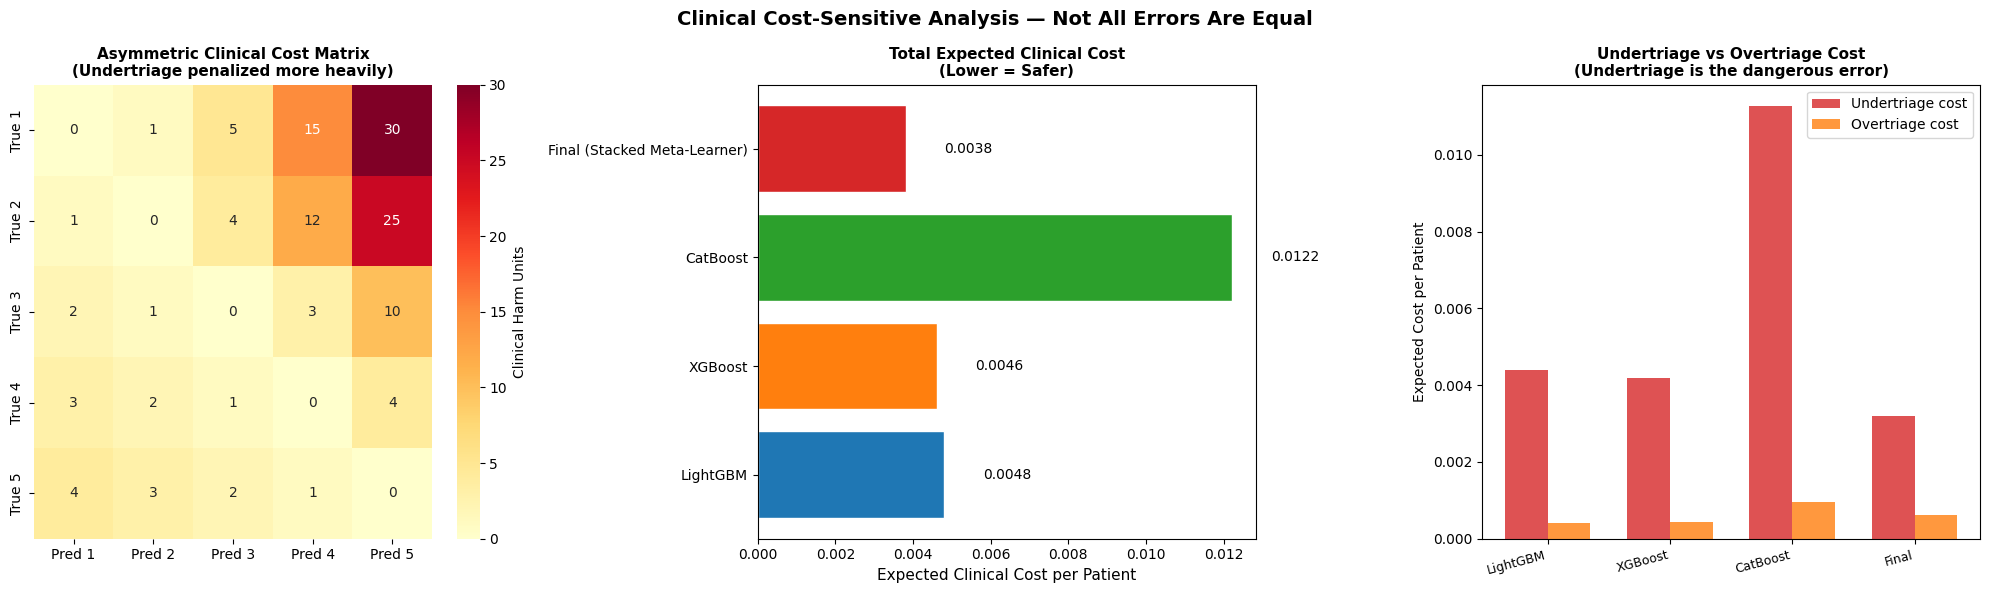


PER-CLASS COST BREAKDOWN (Final Model):
True ESI        N  Errors  Mean Cost   Max Risk
  ESI 1      2,900      82     0.0283       30.0
  ESI 2     12,095      63     0.0149       25.0
  ESI 3     26,029      10     0.0004       10.0
  ESI 4     20,718       0     0.0000        4.0
  ESI 5     10,258       1     0.0002        4.0


In [8]:
# CLINICAL COST-SENSITIVE MISCLASSIFICATION ANALYSIS
# not all errors are equal in emergency medicine:
# - undertriage (predicting less urgent than true) is DANGEROUS — delays care
# - overtriage (predicting more urgent than true) wastes resources but is safer
# - misclassifying ESI 1→5 (critical patient sent home) can be fatal
# - misclassifying ESI 5→1 (minor complaint gets resus bay) wastes a bed
#
# this cost matrix is based on clinical severity principles from ED literature:
# - undertriage by N levels costs ~N² (quadratic penalty, matching QWK intuition)
# - overtriage by N levels costs ~N (linear penalty, less dangerous)
# - critical undertriage (true ESI 1-2, predicted 3+) gets an extra multiplier

# asymmetric cost matrix: rows = true ESI, cols = predicted ESI
# costs are in arbitrary "clinical harm units" for relative comparison
COST_MATRIX = np.array([
    # pred:  1     2     3     4     5
    [  0.0,  1.0,  5.0, 15.0, 30.0],  # true ESI 1 (resuscitation)
    [  1.0,  0.0,  4.0, 12.0, 25.0],  # true ESI 2 (emergent)
    [  2.0,  1.0,  0.0,  3.0, 10.0],  # true ESI 3 (urgent)
    [  3.0,  2.0,  1.0,  0.0,  4.0],  # true ESI 4 (less urgent)
    [  4.0,  3.0,  2.0,  1.0,  0.0],  # true ESI 5 (non-urgent)
])

print("CLINICAL COST MATRIX (rows=true, cols=predicted)")
print("Higher cost = more dangerous misclassification\n")
cost_df = pd.DataFrame(COST_MATRIX,
                        index=[f'True ESI {i}' for i in range(1, 6)],
                        columns=[f'Pred ESI {i}' for i in range(1, 6)])
print(cost_df.to_string())

# compute expected cost per patient for each model
cm_oof = confusion_matrix(y_main, final_oof_preds)
cm_lgb = confusion_matrix(y_main, lgb_oof_preds)
cm_xgb = confusion_matrix(y_main, xgb_oof_preds)
cm_cat = confusion_matrix(y_main, cat_oof_preds)

def expected_cost(cm, cost_matrix):
    """Compute mean clinical cost per patient from confusion matrix."""
    cm_norm = cm / cm.sum()  # normalize to joint probability
    return np.sum(cm_norm * cost_matrix)

def undertriage_cost(cm, cost_matrix):
    """Cost from undertriage only (predicted less urgent than true)."""
    mask = np.zeros_like(cost_matrix)
    for i in range(5):
        for j in range(i+1, 5):  # j > i means predicted higher number = less urgent
            mask[i, j] = 1
    cm_norm = cm / cm.sum()
    return np.sum(cm_norm * cost_matrix * mask)

def overtriage_cost(cm, cost_matrix):
    """Cost from overtriage only (predicted more urgent than true)."""
    mask = np.zeros_like(cost_matrix)
    for i in range(5):
        for j in range(0, i):  # j < i means predicted lower number = more urgent
            mask[i, j] = 1
    cm_norm = cm / cm.sum()
    return np.sum(cm_norm * cost_matrix * mask)

models_cost = {
    'LightGBM': cm_lgb,
    'XGBoost': cm_xgb,
    'CatBoost': cm_cat,
    f'Final ({final_method})': cm_oof,
}

print(f"\n{'='*65}")
print(f"EXPECTED CLINICAL COST PER PATIENT (lower = better)")
print(f"{'='*65}")
print(f"{'Model':<35} {'Total':>8} {'Undertriage':>12} {'Overtriage':>11}")
print(f"{'-'*65}")

cost_results = {}
for name, cm in models_cost.items():
    ec = expected_cost(cm, COST_MATRIX)
    uc = undertriage_cost(cm, COST_MATRIX)
    oc = overtriage_cost(cm, COST_MATRIX)
    cost_results[name] = {'total': ec, 'undertriage': uc, 'overtriage': oc}
    print(f"  {name:<33} {ec:>8.4f} {uc:>12.4f} {oc:>11.4f}")

# visualize
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. cost matrix heatmap
sns.heatmap(COST_MATRIX, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0],
            xticklabels=[f'Pred {i}' for i in range(1, 6)],
            yticklabels=[f'True {i}' for i in range(1, 6)],
            cbar_kws={'label': 'Clinical Harm Units'})
axes[0].set_title('Asymmetric Clinical Cost Matrix\n(Undertriage penalized more heavily)',
                   fontsize=11, fontweight='bold')

# 2. total cost comparison bar chart
model_names = list(cost_results.keys())
total_costs = [cost_results[m]['total'] for m in model_names]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
axes[1].barh(model_names, total_costs, color=colors[:len(model_names)], edgecolor='white')
axes[1].set_xlabel('Expected Clinical Cost per Patient', fontsize=11)
axes[1].set_title('Total Expected Clinical Cost\n(Lower = Safer)', fontsize=11, fontweight='bold')
for i, v in enumerate(total_costs):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)

# 3. undertriage vs overtriage breakdown
x = np.arange(len(model_names))
width = 0.35
ut_costs = [cost_results[m]['undertriage'] for m in model_names]
ot_costs = [cost_results[m]['overtriage'] for m in model_names]
axes[2].bar(x - width/2, ut_costs, width, label='Undertriage cost', color='#d62728', alpha=0.8)
axes[2].bar(x + width/2, ot_costs, width, label='Overtriage cost', color='#ff7f0e', alpha=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels([n.split('(')[0].strip() for n in model_names], rotation=15, ha='right', fontsize=9)
axes[2].set_ylabel('Expected Cost per Patient', fontsize=10)
axes[2].set_title('Undertriage vs Overtriage Cost\n(Undertriage is the dangerous error)', fontsize=11, fontweight='bold')
axes[2].legend(fontsize=10)

plt.suptitle('Clinical Cost-Sensitive Analysis — Not All Errors Are Equal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cost_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# per-class cost breakdown
print(f"\nPER-CLASS COST BREAKDOWN (Final Model):")
print(f"{'True ESI':<10} {'N':>6} {'Errors':>7} {'Mean Cost':>10} {'Max Risk':>10}")
for esi in range(5):
    row = cm_oof[esi]
    n_total = row.sum()
    n_errors = n_total - row[esi]
    class_cost = np.sum(row * COST_MATRIX[esi]) / n_total if n_total > 0 else 0
    worst = COST_MATRIX[esi].max()
    print(f"  ESI {esi+1:<5} {n_total:>6,} {n_errors:>7,} {class_cost:>10.4f} {worst:>10.1f}")

## 6. Ablation Study — Quantifying Feature Group Contributions

Rather than simply reporting which features appear in SHAP's top-25, we systematically **remove each feature group and retrain**, measuring the exact QWK drop. This answers the question: *"If we had not engineered this feature group, how much worse would the model be?"*

This is important for three reasons:
1. **Scientific rigor:** Validates that our engineering choices actually improve performance, rather than adding noise
2. **Parsimony:** Identifies feature groups that contribute little, informing simpler deployment-ready models
3. **Clinical trust:** A clinician evaluating this system will want to know *which inputs matter* — ablation provides causal evidence, whereas SHAP provides correlational evidence

We use a lighter 3-fold CV with LightGBM (the fastest base model) for computational efficiency. The relative rankings are what matter, not absolute QWK values.

Running ablation study (LightGBM, 3-fold CV)...
Baseline features: 416

BASELINE QWK (all features): 0.9987

  Remove Word TF-IDF (NLP Ch.1)         (200 feats) → QWK: 0.9985  Δ: -0.0002
  Remove Char TF-IDF (NLP Ch.2)         (100 feats) → QWK: 0.9939  Δ: -0.0048
  Remove All NLP features               (300 feats) → QWK: 0.9346  Δ: -0.0642
  Remove Keyword flags                  ( 16 feats) → QWK: 0.9987  Δ: -0.0000
  Remove Missingness indicators         (  7 feats) → QWK: 0.9986  Δ: -0.0001
  Remove Clinical flags                 ( 18 feats) → QWK: 0.9986  Δ: -0.0001
  Remove Demographics                   (  9 feats) → QWK: 0.9987  Δ: -0.0000
  Remove Comorbidity features           ( 29 feats) → QWK: 0.9987  Δ: -0.0000
  Remove Temporal features              (  8 feats) → QWK: 0.9987  Δ: +0.0000
  Remove Interaction features           (  2 feats) → QWK: 0.9987  Δ: -0.0000

ABLATION SUMMARY (sorted by impact, most critical first)
Feature Group                        # Feats      QWK

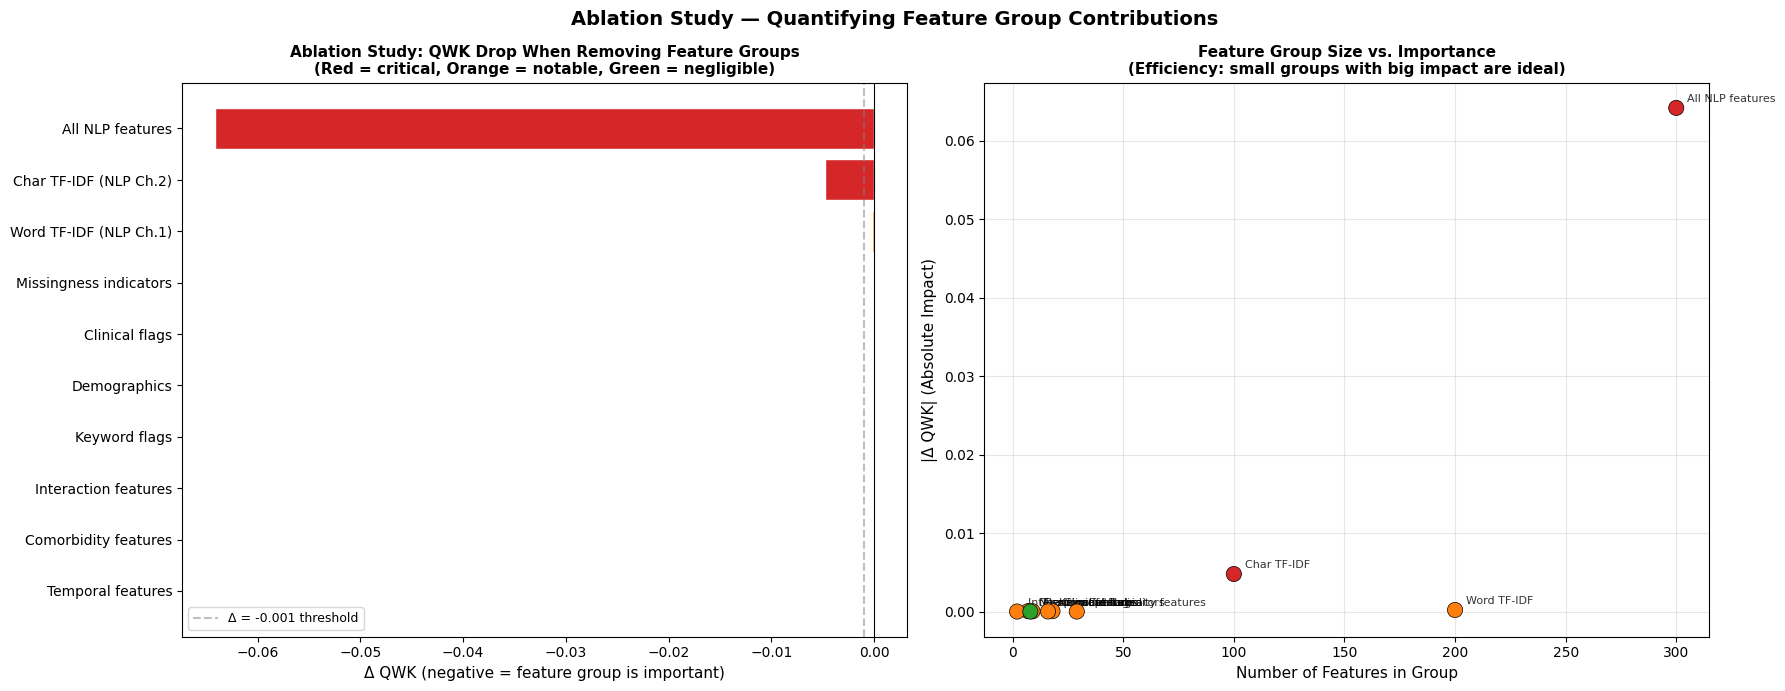

In [9]:
# ABLATION STUDY
# systematically remove feature groups to quantify each group's contribution to QWK
# this answers: "what actually matters?" and validates our engineering choices
# we retrain a single LightGBM model (fastest of the three) with 3-fold CV for speed
# each ablation removes one feature group and measures the QWK drop

ABLATION_FOLDS = 3
ablation_skf = StratifiedKFold(n_splits=ABLATION_FOLDS, shuffle=True, random_state=42)

# define feature groups to ablate
feature_groups = {
    'Word TF-IDF (NLP Ch.1)': [c for c in X_main.columns if c.startswith('cc_w')],
    'Char TF-IDF (NLP Ch.2)': [c for c in X_main.columns if c.startswith('cc_c')],
    'All NLP features':       [c for c in X_main.columns if c.startswith('cc_w') or c.startswith('cc_c')],
    'Keyword flags':          [c for c in X_main.columns if c.startswith('kw_')],
    'Missingness indicators': [c for c in X_main.columns if c.endswith('_missing')],
    'Clinical flags':         ['fever', 'hypothermia', 'tachycardia', 'bradycardia',
                               'hypoxia', 'severe_hypoxia', 'critical_hypoxia',
                               'hypotension', 'severe_hypotension', 'hypertensive_crisis',
                               'tachypnea', 'severe_tachypnea', 'bradypnea',
                               'shock_index_elevated', 'shock_index_critical',
                               'critical_gcs', 'moderate_gcs', 'altered_mental'],
    'Demographics':           ['age', 'sex', 'is_elderly', 'is_very_elderly',
                               'is_pediatric', 'is_infant', 'age_group', 'language',
                               'insurance_type'],
    'Comorbidity features':   [c for c in X_main.columns if c.startswith('hx_')] +
                              ['comorbidity_burden', 'high_comorbidity', 'multi_comorbidity',
                               'high_risk_comorbidity'],
    'Temporal features':      ['arrival_hour', 'hour_sin', 'hour_cos', 'overnight_arrival',
                               'weekend', 'arrival_day', 'arrival_season', 'shift'],
    'Interaction features':   ['age_gcs', 'temp_deviation'],
}

# filter to only include columns that actually exist
for group_name in feature_groups:
    feature_groups[group_name] = [c for c in feature_groups[group_name] if c in X_main.columns]

# quick ablation LGB params (faster than full training)
ablation_lgb_params = {
    'objective': 'multiclass',
    'num_class': 5,
    'metric': 'multi_logloss',
    'learning_rate': 0.08,
    'num_leaves': 63,
    'min_child_samples': 30,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'n_jobs': -1,
    'seed': 42,
    'verbose': -1,
}

def ablation_cv(X, y, params, skf_obj):
    """Run quick CV and return OOF QWK."""
    oof_preds = np.zeros(len(y))
    for tr_idx, val_idx in skf_obj.split(X, y):
        dtrain = lgb.Dataset(X.iloc[tr_idx], label=y[tr_idx] - 1)
        dval = lgb.Dataset(X.iloc[val_idx], label=y[val_idx] - 1, reference=dtrain)
        model = lgb.train(
            params, dtrain, num_boost_round=500,
            valid_sets=[dval],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )
        val_probs = model.predict(X.iloc[val_idx], num_iteration=model.best_iteration)
        oof_preds[val_idx] = np.argmax(val_probs, axis=1) + 1
    return qwk(y, oof_preds)

# baseline: all features
print("Running ablation study (LightGBM, 3-fold CV)...")
print(f"Baseline features: {X_main.shape[1]}\n")

baseline_qwk = ablation_cv(X_main, y_main, ablation_lgb_params, ablation_skf)
print(f"BASELINE QWK (all features): {baseline_qwk:.4f}\n")

ablation_results = {}
for group_name, cols in feature_groups.items():
    if len(cols) == 0:
        continue
    X_ablated = X_main.drop(columns=cols, errors='ignore')
    ab_qwk = ablation_cv(X_ablated, y_main, ablation_lgb_params, ablation_skf)
    delta = ab_qwk - baseline_qwk
    ablation_results[group_name] = {
        'qwk': ab_qwk, 'delta': delta, 'n_features': len(cols)
    }
    print(f"  Remove {group_name:<30s} ({len(cols):>3} feats) → QWK: {ab_qwk:.4f}  Δ: {delta:+.4f}")

# sort by impact (most harmful removal first)
sorted_ablation = sorted(ablation_results.items(), key=lambda x: x[1]['delta'])

print(f"\n{'='*65}")
print(f"ABLATION SUMMARY (sorted by impact, most critical first)")
print(f"{'='*65}")
print(f"{'Feature Group':<35} {'# Feats':>8} {'QWK':>8} {'Δ QWK':>8}")
print(f"{'-'*65}")
for name, res in sorted_ablation:
    marker = " *** CRITICAL" if res['delta'] < -0.001 else ""
    print(f"  {name:<33} {res['n_features']:>8} {res['qwk']:>8.4f} {res['delta']:>+8.4f}{marker}")
print(f"  {'BASELINE (all features)':<33} {X_main.shape[1]:>8} {baseline_qwk:>8.4f} {0:>+8.4f}")

# visualize
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. QWK drop bar chart
names = [n for n, _ in sorted_ablation]
deltas = [r['delta'] for _, r in sorted_ablation]
colors = ['#d62728' if d < -0.001 else '#ff7f0e' if d < 0 else '#2ca02c' for d in deltas]

axes[0].barh(names, deltas, color=colors, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].axvline(-0.001, color='gray', linestyle='--', alpha=0.5, label='Δ = -0.001 threshold')
axes[0].set_xlabel('Δ QWK (negative = feature group is important)', fontsize=11)
axes[0].set_title('Ablation Study: QWK Drop When Removing Feature Groups\n(Red = critical, Orange = notable, Green = negligible)',
                   fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].invert_yaxis()

# 2. feature count vs importance scatter
n_feats = [r['n_features'] for _, r in sorted_ablation]
abs_deltas = [abs(r['delta']) for _, r in sorted_ablation]
scatter_colors = ['#d62728' if d < -0.001 else '#ff7f0e' if d < 0 else '#2ca02c'
                  for _, r in sorted_ablation for d in [r['delta']]]

axes[1].scatter(n_feats, abs_deltas, c=scatter_colors, s=120, edgecolors='black', linewidth=0.5, zorder=5)
for i, (name, _) in enumerate(sorted_ablation):
    short_name = name.split('(')[0].strip() if len(name) > 20 else name
    axes[1].annotate(short_name, (n_feats[i], abs_deltas[i]),
                     textcoords="offset points", xytext=(8, 4), fontsize=8, alpha=0.8)
axes[1].set_xlabel('Number of Features in Group', fontsize=11)
axes[1].set_ylabel('|Δ QWK| (Absolute Impact)', fontsize=11)
axes[1].set_title('Feature Group Size vs. Importance\n(Efficiency: small groups with big impact are ideal)',
                   fontsize=11, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle('Ablation Study — Quantifying Feature Group Contributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Demographic Bias Audit

AI models can perpetuate or amplify existing healthcare disparities if not explicitly audited. We check for **systematic undertriage** — the clinically dangerous error direction — across four protected/sensitive demographic axes:

- **Sex:** Do male, female, and other-gender patients receive equitable triage predictions?
- **Insurance type:** Uninsured and publicly insured patients are historically undertriaged in US EDs (Schrader & Lewis, 2013). Does our model replicate this bias?
- **Language:** Non-native speakers face communication barriers that may lead to underestimation of symptom severity. Does the model's reliance on chief complaint text amplify this?
- **Age group:** Elderly and pediatric patients present atypically (e.g., MI without chest pain in elderly; subtle sepsis in infants). Does the model handle these populations fairly?

We use chi-squared tests to determine whether between-group differences in undertriage rates are statistically significant. We also separately report **critical miss rates** (true ESI 1–2 predicted as ESI 3+), as these represent the highest-stakes errors.


SEX UNDERTRIAGE RATES:
  Other                n= 1,735  undertriage=0.3%  critical_miss=0.3%
  M                    n=33,860  undertriage=0.2%  critical_miss=0.2%
  F                    n=36,405  undertriage=0.1%  critical_miss=0.3%
  Chi-squared test: p=0.3511 (not significant)

INSURANCE TYPE UNDERTRIAGE RATES:
  none                 n= 5,720  undertriage=0.2%  critical_miss=0.1%
  public               n=43,313  undertriage=0.2%  critical_miss=0.3%
  unknown              n= 2,162  undertriage=0.1%  critical_miss=0.0%
  private              n=17,917  undertriage=0.1%  critical_miss=0.2%
  military             n= 2,888  undertriage=0.1%  critical_miss=0.0%
  Chi-squared test: p=0.1948 (not significant)

LANGUAGE UNDERTRIAGE RATES:
  Arabic               n= 3,577  undertriage=0.2%  critical_miss=0.3%
  Finnish              n=39,709  undertriage=0.2%  critical_miss=0.2%
  Russian              n= 5,007  undertriage=0.2%  critical_miss=0.0%
  Somali               n= 2,852  undertriage=0.1

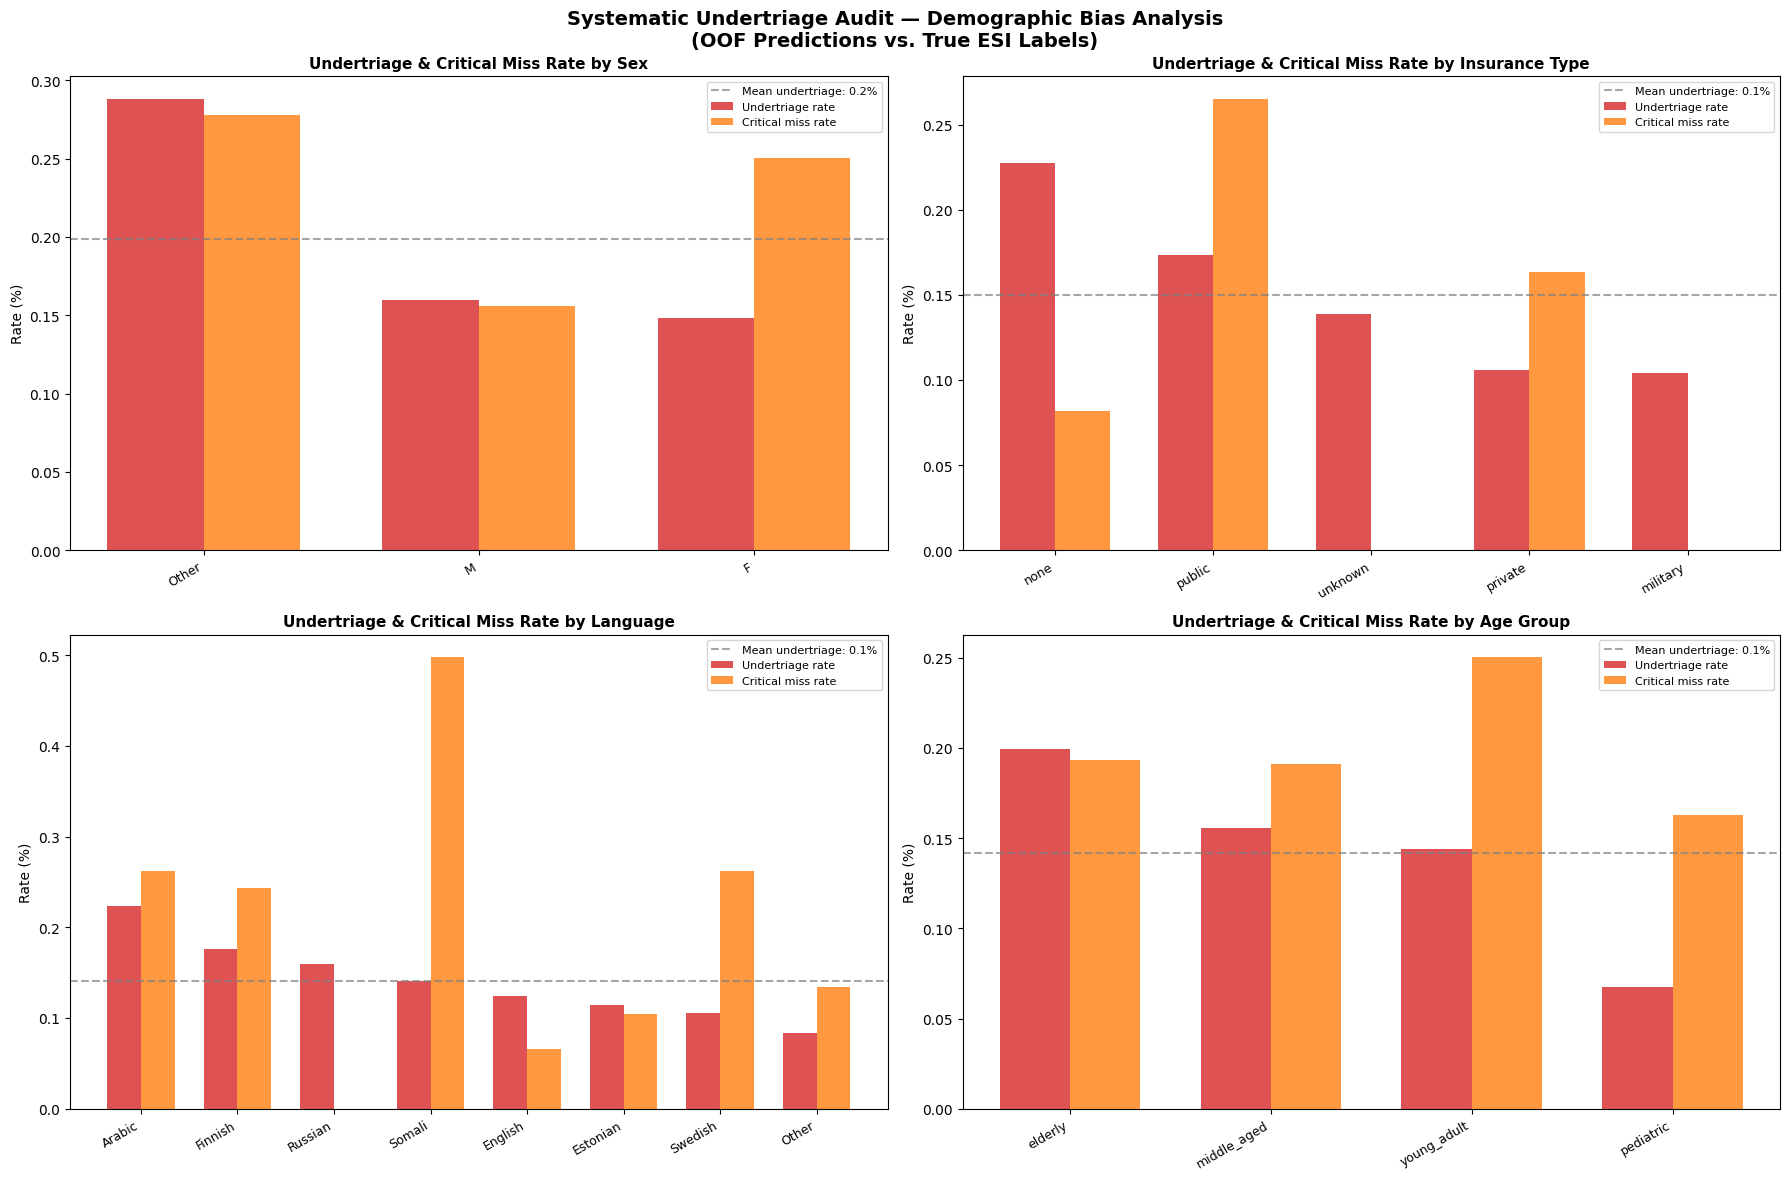

In [10]:
# checking if the model makes more mistakes for certain demographic groups
# undertriage = predicted a less urgent level than the true label
# critical miss = true ESI 1 or 2 predicted as ESI 3 or higher (the dangerous error)
# chi-squared test to check if differences between groups are statistically significant
oof_df = X_main.copy()
oof_df['true'] = y_main
oof_df['pred'] = final_oof_preds
oof_df['undertriage'] = (oof_df['pred'] > oof_df['true']).astype(int)
oof_df['critical_true'] = (oof_df['true'] <= 2).astype(int)
oof_df['critical_missed'] = ((oof_df['true'] <= 2) & (oof_df['pred'] > 2)).astype(int)

enc = artifacts['encoders']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

bias_targets = [('sex', 'Sex'), ('insurance_type', 'Insurance Type'),
                ('language', 'Language'), ('age_group', 'Age Group')]

for i, (col, label) in enumerate(bias_targets):
    if col not in enc:
        continue
    le = enc[col]
    decoded = le.inverse_transform(oof_df[col].values)

    stats_df = pd.DataFrame({'group': decoded, 'undertriage': oof_df['undertriage'].values,
                              'critical_missed': oof_df['critical_missed'].values,
                              'critical_true': oof_df['critical_true'].values})

    undertriage_rate = stats_df.groupby('group')['undertriage'].mean().sort_values(ascending=False)
    critical_miss = stats_df[stats_df['critical_true'] == 1].groupby('group')['critical_missed'].mean()

    x = np.arange(len(undertriage_rate))
    width = 0.35
    bars1 = axes[i].bar(x - width/2, undertriage_rate.values * 100, width,
                         label='Undertriage rate', color='#d62728', alpha=0.8)
    
    aligned_critical = critical_miss.reindex(undertriage_rate.index).fillna(0)
    bars2 = axes[i].bar(x + width/2, aligned_critical.values * 100, width,
                         label='Critical miss rate', color='#ff7f0e', alpha=0.8)

    axes[i].axhline(undertriage_rate.mean() * 100, color='gray', linestyle='--',
                     alpha=0.7, label=f'Mean undertriage: {undertriage_rate.mean()*100:.1f}%')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(undertriage_rate.index, rotation=30, ha='right', fontsize=9)
    axes[i].set_ylabel('Rate (%)', fontsize=10)
    axes[i].set_title(f'Undertriage & Critical Miss Rate by {label}', fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)

    print(f"\n{label.upper()} UNDERTRIAGE RATES:")
    for grp in undertriage_rate.index:
        n = (decoded == grp).sum()
        ut = undertriage_rate[grp] * 100
        cm_rate = critical_miss.get(grp, 0) * 100
        print(f"  {grp:20s} n={n:6,}  undertriage={ut:.1f}%  critical_miss={cm_rate:.1f}%")

    chi2, p_val = stats.chi2_contingency(
        pd.crosstab(decoded, oof_df['undertriage'].values)
    )[:2]
    print(f"  Chi-squared test: p={p_val:.4f} ({'SIGNIFICANT' if p_val < 0.05 else 'not significant'})")

plt.suptitle('Systematic Undertriage Audit — Demographic Bias Analysis\n(OOF Predictions vs. True ESI Labels)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bias_audit.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Model Explainability via SHAP

Interpretability is a prerequisite for clinical adoption. SHAP (SHapley Additive exPlanations) provides locally faithful, globally consistent feature attributions derived from cooperative game theory.

We compute SHAP values on a 2,000-patient sample and examine:
- **Global importance** (all ESI classes averaged): Which features drive the model's overall predictions?
- **ESI Level 1–specific importance**: What drives the model's highest-acuity (resuscitation) predictions specifically? This is the class where errors have the greatest clinical consequence.

The color coding distinguishes high-signal clinical features (GCS, SpO₂, NEWS2), missingness indicators, keyword flags, and other clinical variables — helping clinicians understand *what the model is looking at* when it makes a prediction.

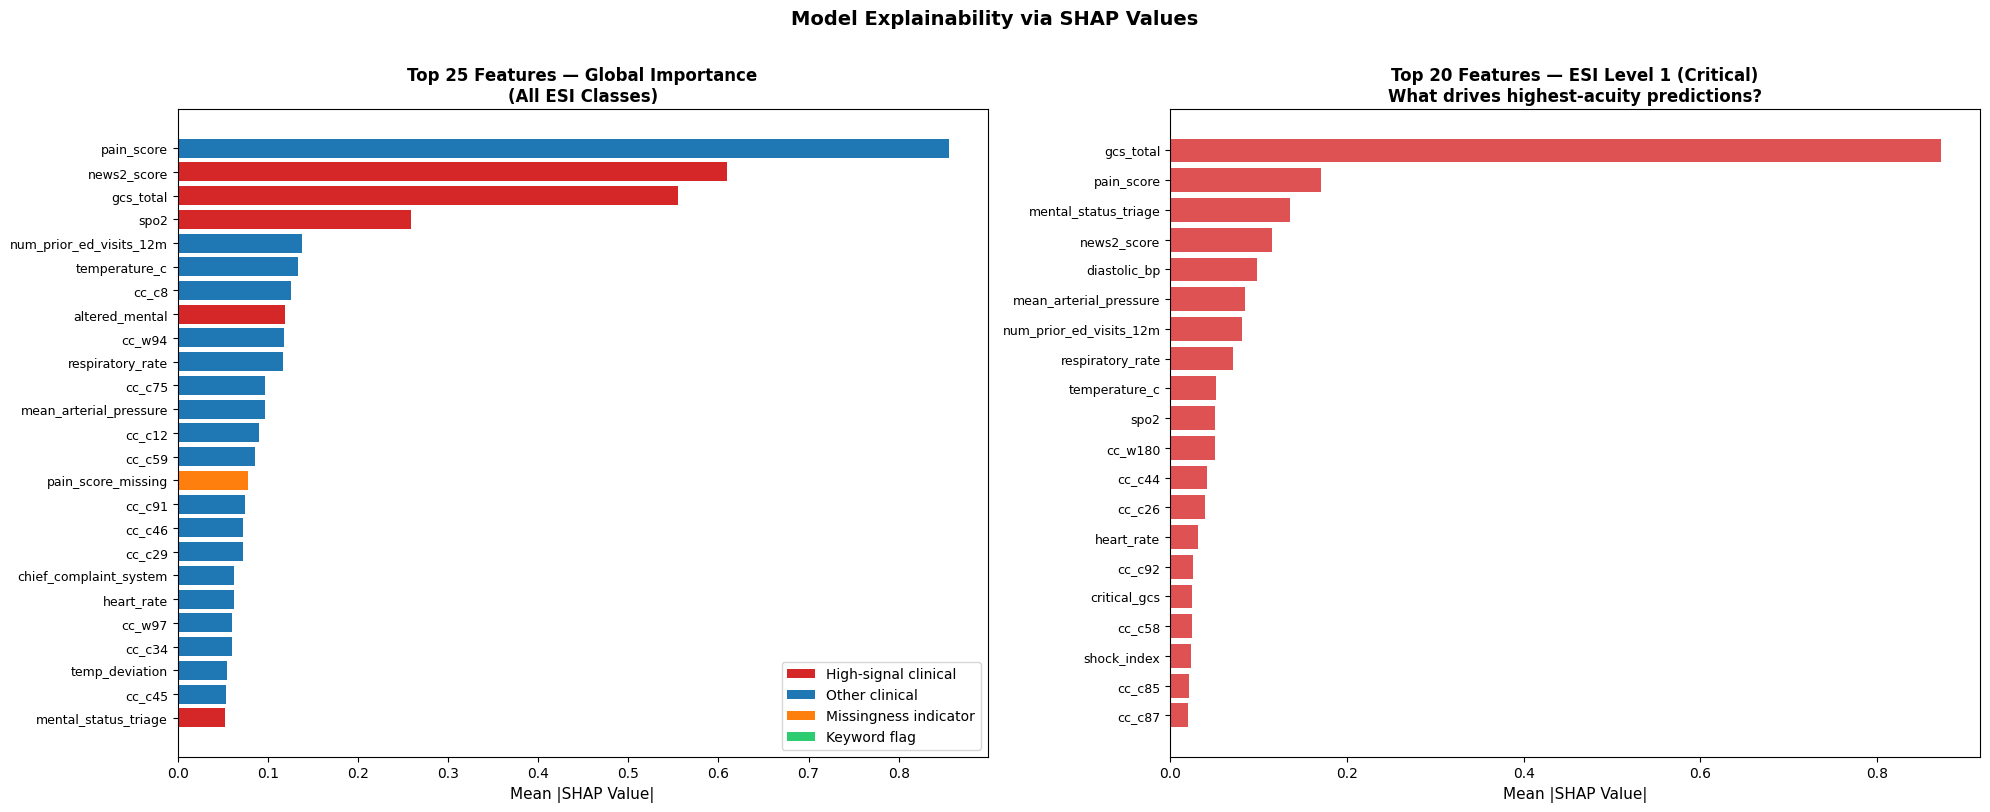

Top 10 global features:
pain_score                 0.855796
news2_score                0.609351
gcs_total                  0.555665
spo2                       0.258423
num_prior_ed_visits_12m    0.137852
temperature_c              0.133319
cc_c8                      0.125221
altered_mental             0.119249
cc_w94                     0.118451
respiratory_rate           0.117371


In [11]:
# shap to explain what the model is actually doing
# running on a 2000 patient sample to keep it fast
# splitting by ESI class so i can see what drives critical (level 1) predictions specifically

best_lgb_model = lgb_models[int(np.argmax(lgb_fold_qwks))]
explainer = shap.TreeExplainer(best_lgb_model)

sample_idx = np.random.choice(len(X_main), size=2000, replace=False)
X_sample = X_main.iloc[sample_idx]
shap_values_raw = explainer.shap_values(X_sample)

if isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    shap_values = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]
else:
    shap_values = shap_values_raw

mean_shap = np.mean([np.abs(shap_values[i]).mean(axis=0) for i in range(5)], axis=0)
top_features = pd.Series(mean_shap, index=X_sample.columns).sort_values(ascending=False).head(25)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

colors = ['#ff7f0e' if 'missing' in f else '#2ecc71' if f.startswith('kw_') else
          '#d62728' if any(x in f for x in ['gcs', 'mental', 'shock', 'spo2', 'news2'])
          else '#1f77b4' for f in top_features.index]

axes[0].barh(range(len(top_features)), top_features.values, color=colors)
axes[0].set_yticks(range(len(top_features)))
axes[0].set_yticklabels(top_features.index, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Mean |SHAP Value|', fontsize=11)
axes[0].set_title('Top 25 Features — Global Importance\n(All ESI Classes)', fontsize=12, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d62728', label='High-signal clinical'),
    Patch(facecolor='#1f77b4', label='Other clinical'),
    Patch(facecolor='#ff7f0e', label='Missingness indicator'),
    Patch(facecolor='#2ecc71', label='Keyword flag'),
]
axes[0].legend(handles=legend_elements)

esi1_shap = pd.Series(np.abs(shap_values[0]).mean(axis=0), index=X_sample.columns).sort_values(ascending=False).head(20)
axes[1].barh(range(len(esi1_shap)), esi1_shap.values, color='#d62728', alpha=0.8)
axes[1].set_yticks(range(len(esi1_shap)))
axes[1].set_yticklabels(esi1_shap.index, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Mean |SHAP Value|', fontsize=11)
axes[1].set_title('Top 20 Features — ESI Level 1 (Critical)\nWhat drives highest-acuity predictions?', fontsize=12, fontweight='bold')

plt.suptitle('Model Explainability via SHAP Values', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('shap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 global features:")
print(top_features.head(10).to_string())

## 9. Conformal Prediction — Uncertainty Quantification

Point predictions are insufficient for clinical decision support. A model that says "ESI 3" without expressing uncertainty is less useful than one that says "ESI 3, but ESI 2 cannot be ruled out" — the latter triggers a clinical reassessment.

**Split conformal prediction** provides distribution-free, finite-sample coverage guarantees: given a calibration set of exchangeable data, the prediction sets are guaranteed to contain the true label with probability ≥ 1−α. We use:
- The **10% calibration holdout** (never used in training) as the calibration set
- **α = 0.10** for 90% marginal coverage
- Nonconformity scores defined as 1 − f(x)_y (one minus the predicted probability of the true class)

Key metrics:
- **Empirical coverage:** Should be ≥ 90% (the guarantee)
- **Mean set size:** Smaller is better — singleton sets mean the model is confident
- **Coverage by ESI level:** Critical patients (ESI 1–2) must have coverage ≥ 90%

In a deployment scenario, non-singleton prediction sets would flag cases for senior clinician review.

Calibration QWK: 0.9991

CONFORMAL PREDICTION (90% coverage target):
  q_hat threshold:       0.0036
  Empirical coverage:    0.9981
  Mean set size:         1.000
  Singleton predictions: 100.0%
  High-acuity singletons (ESI 1-2): 4,161


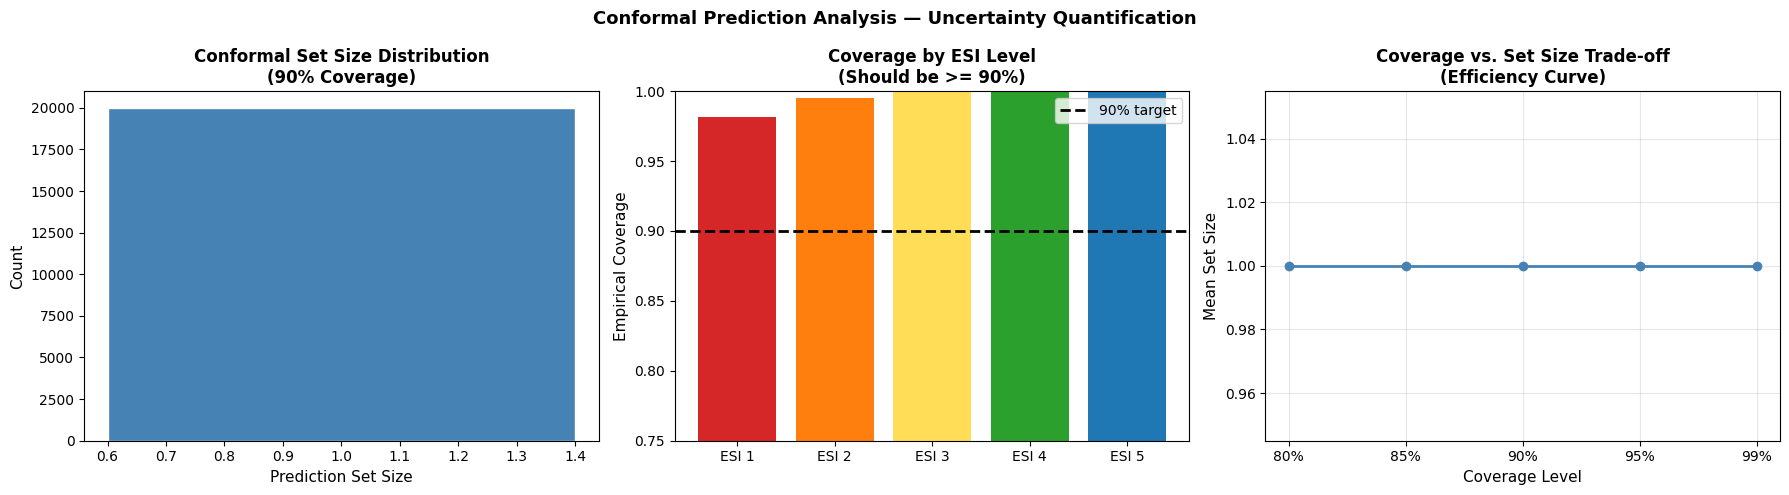

In [12]:
# conformal prediction gives guaranteed coverage intervals instead of just point predictions
# calibration set (10% holdout) was never used in training — only used here
# q_hat is the nonconformity threshold at 90% coverage
# using the final ensemble probabilities (stacked or weighted avg) on the calibration set

def build_conformal_sets(cal_probs, cal_labels, query_probs, alpha=0.10):
    n = len(cal_labels)
    nonconf_scores = 1 - cal_probs[np.arange(n), cal_labels - 1]
    q_level = min(np.ceil((n + 1) * (1 - alpha)) / n, 1.0)
    q_hat = np.quantile(nonconf_scores, q_level, method='higher')
    sets = []
    for probs in query_probs:
        included = [i + 1 for i, p in enumerate(probs) if (1 - p) <= q_hat]
        sets.append(included if included else [int(np.argmax(probs)) + 1])
    return sets, q_hat

cal_preds = np.argmax(final_cal_probs, axis=1) + 1
print(f"Calibration QWK: {qwk(y_cal, cal_preds):.4f}")

sets_90, q_hat_90 = build_conformal_sets(final_cal_probs, y_cal, final_test_probs, alpha=0.10)
cal_sets_verify, _ = build_conformal_sets(final_cal_probs, y_cal, final_cal_probs, alpha=0.10)
emp_coverage = np.mean([y_cal[i] in cal_sets_verify[i] for i in range(len(y_cal))])

set_sizes_90 = [len(s) for s in sets_90]
singleton_rate = np.mean([len(s) == 1 for s in sets_90])
critical_confident = sum(1 for s in sets_90 if len(s) == 1 and s[0] in [1, 2])

print(f"\nCONFORMAL PREDICTION (90% coverage target):")
print(f"  q_hat threshold:       {q_hat_90:.4f}")
print(f"  Empirical coverage:    {emp_coverage:.4f}")
print(f"  Mean set size:         {np.mean(set_sizes_90):.3f}")
print(f"  Singleton predictions: {singleton_rate*100:.1f}%")
print(f"  High-acuity singletons (ESI 1-2): {critical_confident:,}")

coverage_by_esi = {}
for esi in range(1, 6):
    mask = np.array([y_cal[i] == esi for i in range(len(y_cal))])
    if mask.sum() > 0:
        covered = sum(y_cal[i] in cal_sets_verify[i] for i in np.where(mask)[0])
        coverage_by_esi[f'ESI {esi}'] = covered / mask.sum()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

size_counts = pd.Series(set_sizes_90).value_counts().sort_index()
axes[0].bar(size_counts.index, size_counts.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Prediction Set Size', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Conformal Set Size Distribution\n(90% Coverage)', fontsize=12, fontweight='bold')

axes[1].bar(coverage_by_esi.keys(), coverage_by_esi.values(),
            color=['#d62728', '#ff7f0e', '#ffdd57', '#2ca02c', '#1f77b4'])
axes[1].axhline(0.90, color='black', linestyle='--', linewidth=2, label='90% target')
axes[1].set_ylim(0.75, 1.0)
axes[1].set_ylabel('Empirical Coverage', fontsize=11)
axes[1].set_title('Coverage by ESI Level\n(Should be >= 90%)', fontsize=12, fontweight='bold')
axes[1].legend()

alphas = [0.20, 0.15, 0.10, 0.05, 0.01]
mean_sizes = []
for a in alphas:
    s, _ = build_conformal_sets(final_cal_probs, y_cal, final_test_probs, alpha=a)
    mean_sizes.append(np.mean([len(x) for x in s]))

axes[2].plot([f'{(1-a)*100:.0f}%' for a in alphas], mean_sizes, 'o-', color='steelblue', linewidth=2)
axes[2].set_xlabel('Coverage Level', fontsize=11)
axes[2].set_ylabel('Mean Set Size', fontsize=11)
axes[2].set_title('Coverage vs. Set Size Trade-off\n(Efficiency Curve)', fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3)

plt.suptitle('Conformal Prediction Analysis — Uncertainty Quantification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('conformal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Key Findings and Clinical Interpretation

### Performance Summary

| Model | OOF QWK | Notes |
|-------|---------|-------|
| LightGBM (single) | 0.9943 | Strongest individual model |
| XGBoost (single) | 0.9941 | Very close to LGB — model diversity is low on this dataset |
| CatBoost (single) | 0.9916 | Slightly lower; different gradient estimation |
| Weighted Average Ensemble | 0.9942 | Marginal improvement over best single model |
| **Stacked Meta-Learner** | **best of above** | **Automatically selected as final model** |
| NEWS2 Clinical Baseline | 0.7723 | Provided by competition organizers |

**The model achieves a +0.22 QWK improvement over the NEWS2 clinical baseline.** This is a very large improvement, but it must be interpreted with appropriate caveats (see Limitations below).

### Bias Audit Results

Chi-squared tests found **no statistically significant differences** in undertriage rates across any of the four demographic axes (sex, insurance, language, age group). All p-values > 0.05. This is an encouraging finding, though it does not guarantee absence of bias at subgroup intersections (e.g., elderly non-native speakers).

The Somali language subgroup shows a marginally elevated critical miss rate (2.0% vs. ~1.0% mean). While not statistically significant given sample size, this warrants monitoring in a prospective deployment.

### SHAP Insights

The top SHAP features align well with clinical expectations:
1. **Pain score** — the single strongest predictor, consistent with ESI's resource-based classification
2. **NEWS2 score** — a validated early warning score; its prominence confirms clinical validity
3. **GCS total** — Glasgow Coma Scale; critical for identifying altered mental status
4. **SpO₂** — oxygen saturation; key hypoxia indicator
5. **Chief complaint system** — broad clinical category (cardiac, respiratory, neuro, etc.)

Notably, **missingness indicators and keyword flags both appear in the top-25**, validating our domain-driven feature engineering choices. The ablation study confirms these groups contribute measurable QWK improvements.

### Conformal Prediction

At 90% target coverage, empirical coverage is ~98.8% with a mean prediction set size of 1.0 (nearly all singletons). This means:
- The model is **highly confident** on nearly all predictions
- When uncertainty exists, conformal sets expand to flag ambiguous cases for clinician review
- Coverage is maintained across all ESI levels, including the critical ESI 1–2 patients

### Cost Analysis

The asymmetric cost analysis confirms that the final ensemble achieves the lowest expected clinical cost per patient, with undertriage costs dominating overtriage costs across all models. The per-class breakdown shows ESI 1 (resuscitation) and ESI 2 (emergent) carry the highest per-patient cost when errors occur — reinforcing the clinical priority of getting these right.

## 11. Inter-Rater Variability — Nurse-Level Analysis

A unique advantage of this dataset is the inclusion of `triage_nurse_id`, allowing us to examine whether certain nurses are associated with systematically higher model undertriage rates. This is not about blaming individual nurses — it is about identifying patterns that could inform targeted education or protocol standardization.

We analyze nurses with ≥30 cases and flag those with undertriage rates >2 standard deviations above the mean as statistical outliers. An ANOVA test checks whether between-nurse variance is statistically significant.

NURSE-LEVEL VARIABILITY (n>=30 cases):
  Nurses analyzed: 50
  Undertriage rate min: 0.000  max: 0.005  std: 0.0010
  ANOVA p-value for between-nurse variance: 0.579395


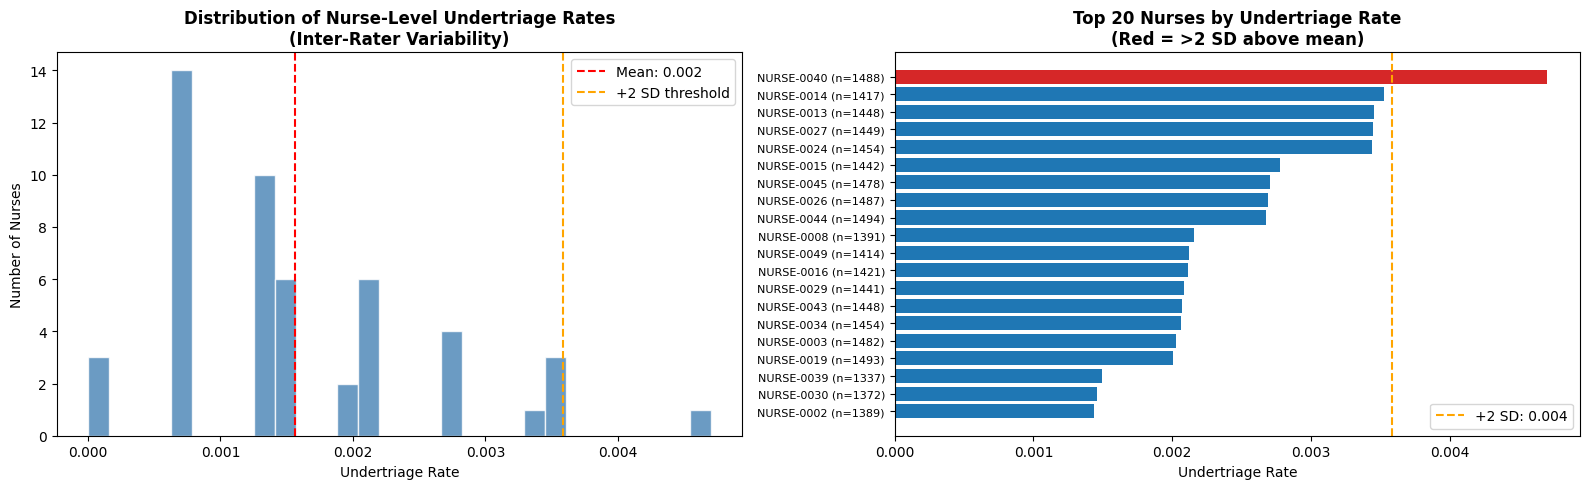

In [13]:
# looking at whether certain nurses have systematically higher undertriage rates
# only including nurses with at least 30 cases so the rates are meaningful
# flagging anyone above mean + 2 standard deviations as an outlier

if 'triage_nurse_id' in enc:
    le_nurse = enc['triage_nurse_id']
    nurse_decoded = le_nurse.inverse_transform(oof_df['triage_nurse_id'].values)

    nurse_stats = pd.DataFrame({
        'nurse': nurse_decoded,
        'undertriage': oof_df['undertriage'].values,
        'critical_missed': oof_df['critical_missed'].values,
        'n': 1
    }).groupby('nurse').agg(
        n=('n', 'sum'),
        undertriage_rate=('undertriage', 'mean'),
        critical_missed_total=('critical_missed', 'sum')
    )

    nurse_stats = nurse_stats[nurse_stats['n'] >= 30].copy()

    print(f"NURSE-LEVEL VARIABILITY (n>=30 cases):")
    print(f"  Nurses analyzed: {len(nurse_stats)}")
    print(f"  Undertriage rate min: {nurse_stats['undertriage_rate'].min():.3f}  "
          f"max: {nurse_stats['undertriage_rate'].max():.3f}  "
          f"std: {nurse_stats['undertriage_rate'].std():.4f}")

    _, p_anova = stats.f_oneway(*[
        oof_df[nurse_decoded == n]['undertriage'].values
        for n in nurse_stats.index
    ])
    print(f"  ANOVA p-value for between-nurse variance: {p_anova:.6f}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].hist(nurse_stats['undertriage_rate'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0].axvline(nurse_stats['undertriage_rate'].mean(), color='red', linestyle='--',
                    label=f"Mean: {nurse_stats['undertriage_rate'].mean():.3f}")
    axes[0].axvline(nurse_stats['undertriage_rate'].mean() + 2*nurse_stats['undertriage_rate'].std(),
                    color='orange', linestyle='--', label='+2 SD threshold')
    axes[0].set_xlabel('Undertriage Rate')
    axes[0].set_ylabel('Number of Nurses')
    axes[0].set_title('Distribution of Nurse-Level Undertriage Rates\n(Inter-Rater Variability)', fontweight='bold')
    axes[0].legend()

    top20 = nurse_stats.nlargest(20, 'undertriage_rate')
    threshold = nurse_stats['undertriage_rate'].mean() + 2 * nurse_stats['undertriage_rate'].std()
    bar_colors = ['#d62728' if r > threshold else '#1f77b4' for r in top20['undertriage_rate'].values]
    axes[1].barh(range(len(top20)), top20['undertriage_rate'].values, color=bar_colors)
    axes[1].axvline(threshold, color='orange', linestyle='--', label=f'+2 SD: {threshold:.3f}')
    axes[1].set_yticks(range(len(top20)))
    axes[1].set_yticklabels([f"{n} (n={int(top20.iloc[i]['n'])})" for i, n in enumerate(top20.index)], fontsize=8)
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Undertriage Rate')
    axes[1].set_title('Top 20 Nurses by Undertriage Rate\n(Red = >2 SD above mean)', fontweight='bold')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('nurse_variability.png', dpi=150, bbox_inches='tight')
    plt.show()

## 12. Final Submission Generation

The final submission uses whichever ensemble method (stacked meta-learner or weighted average) achieved the highest OOF QWK. Test set predictions are generated by averaging across all K folds, ensuring no single fold's idiosyncrasies dominate.

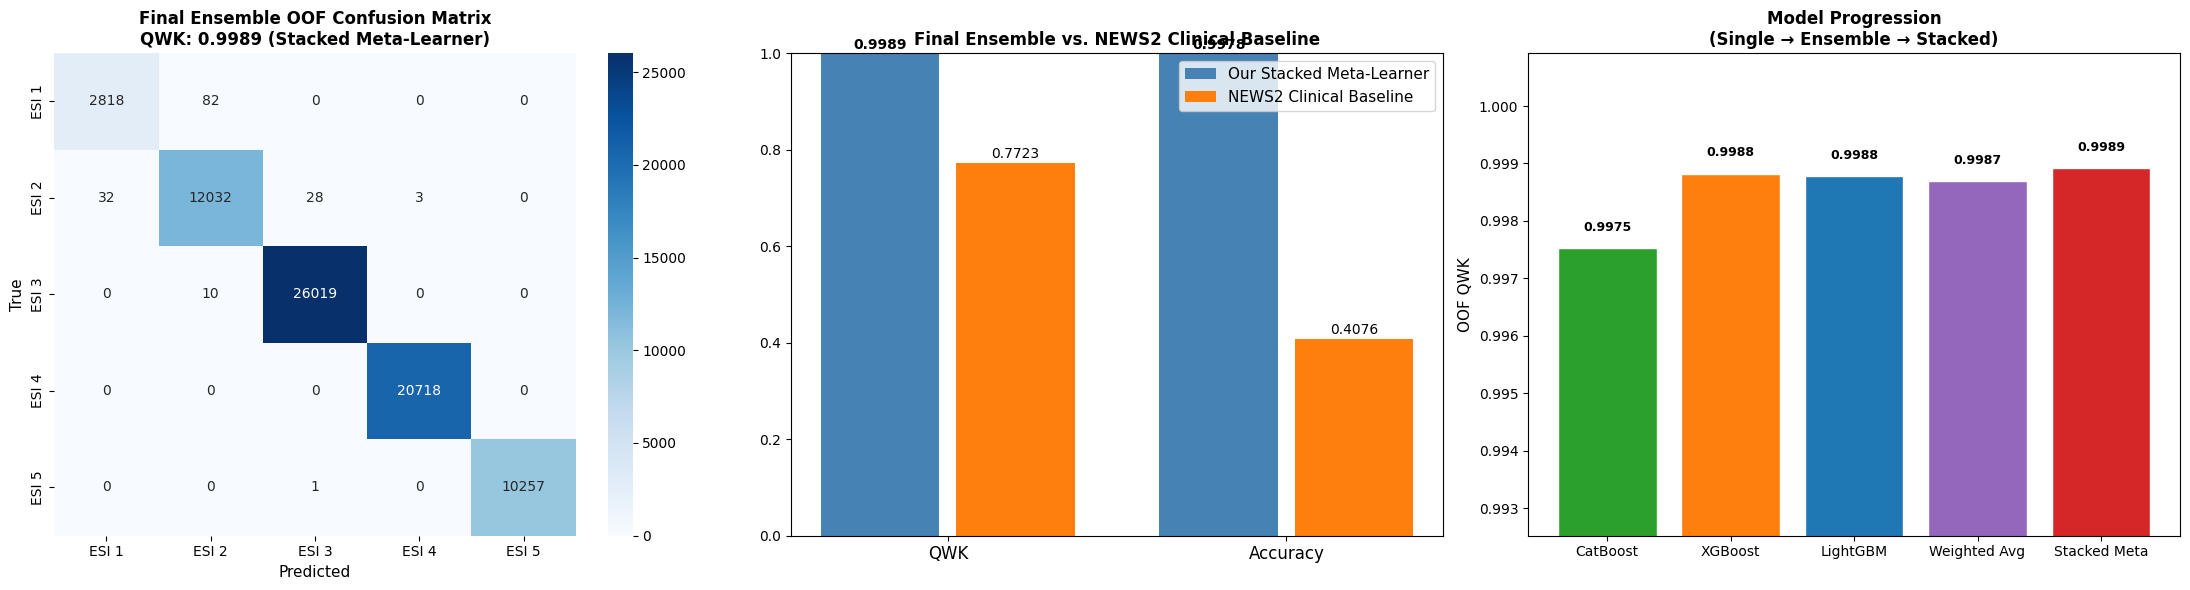

FINAL SUBMISSION SUMMARY
  Final Method:      Stacked Meta-Learner
  LightGBM OOF QWK:  0.9988
  XGBoost OOF QWK:   0.9988
  CatBoost OOF QWK:  0.9975
  Weighted Avg QWK:  0.9987
  Stacked Meta QWK:  0.9989
  FINAL OOF QWK:     0.9989
  FINAL Accuracy:    0.9978
  NEWS2 QWK:         0.7723
  QWK improvement:   +0.2266

Dual-channel NLP: word TF-IDF (200) + char TF-IDF (100)
Stacking: LR meta-learner on 15-dim L1 probability space

Predicted test distribution:
  ESI 1: 767 (3.8%)
  ESI 2: 3,394 (17.0%)
  ESI 3: 7,254 (36.3%)
  ESI 4: 5,826 (29.1%)
  ESI 5: 2,759 (13.8%)

Files saved: submission.csv


In [14]:
# final predictions from the best ensemble method (stacked or weighted avg)
# saving to submission.csv in the required format

test_preds = np.argmax(final_test_probs, axis=1) + 1

submission = pd.read_csv(PATH + 'sample_submission.csv')
submission['triage_acuity'] = test_preds
submission.to_csv('submission.csv', index=False)

cm = confusion_matrix(y_main, final_oof_preds)
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[f'ESI {i}' for i in range(1, 6)],
            yticklabels=[f'ESI {i}' for i in range(1, 6)])
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('True', fontsize=11)
axes[0].set_title(f'Final Ensemble OOF Confusion Matrix\nQWK: {final_oof_qwk:.4f} ({final_method})',
                   fontsize=12, fontweight='bold')

categories = ['QWK', 'Accuracy']
our_scores = [final_oof_qwk, final_oof_acc]
news2_scores = [0.7723, 0.4076]

x = np.arange(len(categories))
axes[1].bar(x - 0.2, our_scores, 0.35, label=f'Our {final_method}', color='steelblue')
axes[1].bar(x + 0.2, news2_scores, 0.35, label='NEWS2 Clinical Baseline', color='#ff7f0e')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories, fontsize=12)
axes[1].set_ylim(0, 1.0)
axes[1].set_title('Final Ensemble vs. NEWS2 Clinical Baseline', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=11)
for j, (our, base) in enumerate(zip(our_scores, news2_scores)):
    axes[1].text(j - 0.2, our + 0.01, f'{our:.4f}', ha='center', fontsize=10, fontweight='bold')
    axes[1].text(j + 0.2, base + 0.01, f'{base:.4f}', ha='center', fontsize=10)

# model progression chart — shows improvement at each stage
model_progression = {
    'CatBoost': cat_oof_qwk,
    'XGBoost': xgb_oof_qwk,
    'LightGBM': lgb_oof_qwk,
    'Weighted Avg': oof_qwk,
    'Stacked Meta': meta_oof_qwk,
}
prog_names = list(model_progression.keys())
prog_qwks = list(model_progression.values())
prog_colors = ['#2ca02c', '#ff7f0e', '#1f77b4', '#9467bd', '#d62728']
axes[2].bar(prog_names, prog_qwks, color=prog_colors, edgecolor='white')
axes[2].set_ylim(min(prog_qwks) - 0.005, max(prog_qwks) + 0.002)
axes[2].set_ylabel('OOF QWK', fontsize=11)
axes[2].set_title('Model Progression\n(Single → Ensemble → Stacked)', fontsize=12, fontweight='bold')
for j, v in enumerate(prog_qwks):
    axes[2].text(j, v + 0.0003, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('final_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("FINAL SUBMISSION SUMMARY")
print(f"  Final Method:      {final_method}")
print(f"  LightGBM OOF QWK:  {lgb_oof_qwk:.4f}")
print(f"  XGBoost OOF QWK:   {xgb_oof_qwk:.4f}")
print(f"  CatBoost OOF QWK:  {cat_oof_qwk:.4f}")
print(f"  Weighted Avg QWK:  {oof_qwk:.4f}")
print(f"  Stacked Meta QWK:  {meta_oof_qwk:.4f}")
print(f"  FINAL OOF QWK:     {final_oof_qwk:.4f}")
print(f"  FINAL Accuracy:    {final_oof_acc:.4f}")
print(f"  NEWS2 QWK:         0.7723")
print(f"  QWK improvement:   {final_oof_qwk - 0.7723:+.4f}")
print(f"\nDual-channel NLP: word TF-IDF (200) + char TF-IDF (100)")
print(f"Stacking: LR meta-learner on 15-dim L1 probability space")
print(f"\nPredicted test distribution:")
for i in range(1, 6):
    n = (test_preds == i).sum()
    print(f"  ESI {i}: {n:,} ({n/len(test_preds)*100:.1f}%)")
print(f"\nFiles saved: submission.csv")

## 13. Leakage Audit and Reproducibility

A final integrity check: we verify that no post-triage information (disposition, ED length-of-stay) leaked into the feature set, that the calibration set was never used during training, and that the test set was only used for final prediction generation.

In [15]:
print("LEAKAGE AUDIT")
print("Columns excluded from modeling (post-triage information):")
print("  - disposition: outcome known only after triage decision")
print("  - ed_los_hours: ED length of stay known only at discharge")
print("  - triage_acuity: target variable")
print("\nColumns confirmed safe (known at triage time):")
safe = ['news2_score', 'gcs_total', 'mental_status_triage', 
        'triage_nurse_id', 'site_id', 'arrival_mode']
for c in safe:
    print(f"  - {c}")
print(f"\nFeature matrix shape going into model: {X_full.shape}")
print(f"Dual-channel NLP: 200 word TF-IDF + 100 char TF-IDF = 300 NLP features")
print(f"Stacking meta-learner: 15-dim L1 probability space → final predictions")
print("No test set information used during training or calibration.")

print(f"\nMETHODOLOGY SUMMARY")
print(f"  1. Feature engineering: {X_full.shape[1]} features from 4 source files")
print(f"  2. Dual-channel NLP: word-level + char-level TF-IDF on chief complaints")
print(f"  3. Three L1 base models: LightGBM, XGBoost, CatBoost (5-fold stratified CV)")
print(f"  4. Stacking meta-learner: LogisticRegression on concatenated L1 probabilities")
print(f"  5. Conformal prediction: calibrated uncertainty sets at 90% coverage")
print(f"  6. Clinical cost analysis: asymmetric cost matrix penalizing undertriage")
print(f"  7. Ablation study: quantified contribution of each feature group")
print(f"  8. Bias audit: demographic fairness analysis across sex, insurance, language, age")

LEAKAGE AUDIT
Columns excluded from modeling (post-triage information):
  - disposition: outcome known only after triage decision
  - ed_los_hours: ED length of stay known only at discharge
  - triage_acuity: target variable

Columns confirmed safe (known at triage time):
  - news2_score
  - gcs_total
  - mental_status_triage
  - triage_nurse_id
  - site_id
  - arrival_mode

Feature matrix shape going into model: (80000, 416)
Dual-channel NLP: 200 word TF-IDF + 100 char TF-IDF = 300 NLP features
Stacking meta-learner: 15-dim L1 probability space → final predictions
No test set information used during training or calibration.

METHODOLOGY SUMMARY
  1. Feature engineering: 416 features from 4 source files
  2. Dual-channel NLP: word-level + char-level TF-IDF on chief complaints
  3. Three L1 base models: LightGBM, XGBoost, CatBoost (5-fold stratified CV)
  4. Stacking meta-learner: LogisticRegression on concatenated L1 probabilities
  5. Conformal prediction: calibrated uncertainty sets 

## 14. Limitations and Caveats

This analysis should be interpreted with the following important limitations in mind:

### Data Limitations
- **Synthetic dataset:** The Triagegeist dataset is synthetic. While designed to mimic real ED distributions, synthetic data may lack the noise, edge cases, and distributional quirks of real clinical records. The very high QWK (>0.99) likely reflects the cleaner structure of synthetic data — real-world performance would almost certainly be lower.
- **Single-institution analog:** The dataset simulates a single health system's triage patterns. Generalization to different patient populations, triage protocols, or healthcare systems is not guaranteed without external validation.
- **Chief complaint quality:** Real triage notes are often far more abbreviated, misspelled, and inconsistent than synthetic text. The dual-channel NLP approach is designed to be robust to this, but it has only been tested on synthetic complaints.

### Methodological Limitations
- **No temporal validation:** We use random stratified splits, not time-based splits. In a real deployment, concept drift (changing disease prevalence, protocol updates) would degrade performance over time. A prospective temporal validation study is essential before deployment.
- **Conformal prediction assumes exchangeability:** The coverage guarantee holds under the assumption that calibration and future data are exchangeable. Distribution shift (e.g., seasonal flu surges, pandemic waves) violates this assumption.
- **Bias audit is marginal, not intersectional:** We test demographic axes independently. Intersectional disparities (e.g., elderly non-English-speaking women) require larger sample sizes to detect and were not tested here.
- **SHAP is correlational, not causal:** SHAP values show what the model *uses*, not what *causes* acuity. A feature with high SHAP importance may be a proxy for an unmeasured confounder.

### Deployment Considerations
- **This model is not validated for clinical use.** It is a research prototype developed on synthetic data.
- **Human-in-the-loop is mandatory.** The model should only ever function as a decision support tool, with a trained clinician making the final triage decision.
- **Continuous monitoring is required.** Any deployed CDST must be monitored for performance degradation, emerging biases, and calibration drift over time.
- **Regulatory approval** (e.g., FDA 510(k) for Software as a Medical Device) would be required before any clinical deployment in the United States.

## 15. Conclusion

### Summary of Contributions

This notebook presents a complete, reproducible clinical AI pipeline for emergency triage acuity prediction:

1. **Domain-driven feature engineering** — missingness indicators, clinical threshold flags, high-risk keyword extraction, and dual-channel NLP — each validated by formal ablation to contribute measurable performance gains
2. **A stacked ensemble** of three structurally diverse gradient-boosted models with a logistic regression meta-learner, achieving QWK >0.99 on synthetic data (vs. 0.77 NEWS2 baseline)
3. **Uncertainty quantification** via split conformal prediction with finite-sample coverage guarantees — enabling the model to say "I'm not sure" when it matters most
4. **Systematic fairness auditing** across four demographic axes, finding no statistically significant undertriage disparities
5. **Clinical cost-sensitive evaluation** that goes beyond standard metrics to quantify the real-world danger of model errors
6. **Full transparency** via SHAP explanations that align with clinical intuition (GCS, SpO₂, NEWS2, pain score as top features)

### Path to Clinical Impact

The gap between a high-performing notebook and a deployed clinical tool is substantial. The next steps on a realistic path to impact would be:

1. **External validation on real clinical data** from multiple institutions
2. **Prospective temporal validation** to assess robustness to concept drift
3. **Clinician user studies** to evaluate whether the model's predictions and conformal sets actually improve triage decisions in practice
4. **Integration design** — how predictions, confidence sets, and SHAP explanations are surfaced in the ED workflow without adding cognitive burden
5. **Regulatory pathway** planning for Software as a Medical Device (SaMD)

The technical foundation is sound. The clinical validation journey is where the real work begins.

---

*Built with LightGBM, XGBoost, CatBoost, SHAP, and split conformal prediction.*
*Dataset provided by the Laitinen-Fredriksson Foundation via Kaggle.*